# Evaluación experimental del catálogo v3 — DEC-MRTAU

**TFM: Asignación distribuida de tareas multi-robot bajo incertidumbre.** Manuel Olías.

Este cuaderno recoge la evaluación comparativa de las cinco políticas de asignación distribuida
implementadas en el trabajo —`random`, `greedy`, `CBAA`, `CBBA` y `Dec-MCTS`— sobre el **catálogo
v3**, el conjunto de escenarios definitivo: 360 escenarios repartidos en **cinco bloques de 72**,
cada uno de los cuales varía **un único factor** del problema sobre una configuración de
referencia común.

El propósito es doble: **cuantificar el rendimiento relativo** de las cinco políticas y
**caracterizar las condiciones experimentales bajo las cuales ese rendimiento cambia**. Se
reportan todos los cortes definidos por el diseño del catálogo, con independencia de a qué
política favorezcan; los criterios de comparación se fijan en esta introducción y se aplican sin
excepción en el resto del documento.

| Parte | Contenido |
|---|---|
| **1 · Análisis conjunto** | Los 360 escenarios como un único conjunto: recompensa media, diferencia pareada entre los dos solvers de cabeza, dominancia entre todas las parejas y **sensibilidad del resultado agregado a la composición del catálogo**. |
| **2 · Análisis por bloque** | Un apartado por bloque, con el contraste que cada uno fue diseñado para medir: tamaño del equipo (A), forma de la ventana (B), carga por robot (C), coaliciones (D) y nivel de incertidumbre (E). |
| **3 · Análisis adicional** | Magnitudes registradas por el simulador distintas de la métrica objetivo: robots perdidos, descomposición de la recompensa, distancia recorrida, tiempo de cómputo y ocupación del horizonte temporal. |

---

### Datos

| | |
|---|---|
| Escenarios | `scenarios/catalogo_v3/` — 360 escenarios, 5 bloques de 72, 10 896 tareas, 12 264 plazas de trabajador |
| Tanda | `logs/eval_catalogo_v3` — 360 × 5 solvers × 3 réplicas = **5 400 ejecuciones** |
| Tabla | `analisis/catalogo_v3.csv`, generada con `scripts/extract_metrics.py` |
| Equipos | de 2 a 10 robots; escenarios de 6 a 80 tareas; batería de capacidad 40 en todos ellos |
| Regímenes | ρ = 1 / 0.9 / 0.75 / 0.5 con σ de la duración = 0 / 1 / 3 / 5; un intento **fallido** cuesta 10 de batería en todos ellos |

```bash
python3 scripts/extract_metrics.py logs/eval_catalogo_v3 -o analisis/catalogo_v3.csv
```

### Criterios de comparación

Se fijan aquí y no se alteran en ningún apartado posterior:

1. **Métrica objetivo**: `final_reward` = fracción de tareas completadas (`reward00` con
   $k_1 = 1$). Las magnitudes de la parte 3 se identifican explícitamente como secundarias.
2. **Unidad de análisis: el escenario**, promediando sus 3 réplicas. Un escenario contribuye una
   sola observación a cada estadístico.
3. **Comparaciones pareadas por escenario** y **error estándar calculado entre escenarios**. Con
   4–6 instancias distintas por celda, la varianza entre instancias (±0.15) es un orden de
   magnitud mayor que el ruido entre réplicas (±0.016); calcular el error sobre las réplicas
   sobrestimaría la precisión.
4. **Diferencia pareada de referencia**: $\Delta = \text{Dec-MCTS} - \text{CBBA}$. Se detalla esta
   pareja porque son los dos solvers con mayor recompensa media sobre el agregado y la única cuya
   ordenación no queda resuelta por el ranking global; el resto de las parejas se resume en la
   matriz de dominancia de §1.3, que no privilegia a ningún solver.
5. **Convenio de color, constante en todas las figuras**: `Random` gris · `Greedy` morado ·
   `CBAA` verde · **`CBBA` rojo** · **`Dec-MCTS` azul**. En las figuras de diferencias, el rojo
   señala ventaja de CBBA y el azul ventaja de Dec-MCTS, en coherencia con esos dos colores. Los
   cortes que **no** corresponden a un solver (régimen, tamaño de equipo) usan negro, naranja o
   una rampa de grises, para no confundirse con la codificación anterior.

### Advertencias sobre la composición del conjunto

- Los regímenes `det` y `est` están **equilibrados entre bloques** (162 escenarios cada uno, 36
  por bloque salvo E, que aporta 18). Los regímenes `lev` y `fue` existen **solo en el bloque E**
  (18 escenarios cada uno), porque el gradiente de incertidumbre es el factor que ese bloque
  barre. En consecuencia, las figuras cuyo eje recorre los cuatro regímenes se restringen al
  bloque E y así se indica en su título; los cortes globales se leen sobre `det` y `est`.
- La diferencia entre CBBA y Dec-MCTS sobre el agregado no es estadísticamente separable de cero
  en términos prácticos (§1.2) y **su signo depende de qué bloques se incluyan** (§1.4). Por ese
  motivo los resultados se presentan desglosados por bloque y por régimen, y el agregado se
  acompaña siempre de su análisis de sensibilidad.

## 0 · Datos, convenios y funciones auxiliares

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
import matplotlib as mpl, matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
from pathlib import Path

RUTA = Path('catalogo_v3.csv') if Path('catalogo_v3.csv').exists() else Path('analisis/catalogo_v3.csv')
FIGS = RUTA.parent / 'figuras'; FIGS.mkdir(exist_ok=True)

# ── Paleta base (validada para daltonismo: CVD ΔE 9.2, visión normal 16.3, all-pairs) ──
INK, INK2, MUTED    = '#0b0b0b', '#52514e', '#898781'
GRID, AXIS, SURFACE = '#e1e0d9', '#c3c2b7', '#fcfcfb'
NEG, POS, MID       = '#e34948', '#2a78d6', '#f0efec'      # rojo ↔ azul (escala divergente)
DIV = LinearSegmentedColormap.from_list('div', [NEG, MID, POS])   # solo para DIFERENCIAS
SEQ = LinearSegmentedColormap.from_list('seq', [SURFACE, '#2f2e2b'])  # magnitudes sin signo

# ── Color fijo por solver, idéntico en todas las figuras del cuaderno ──
COLOR  = {'random': MUTED, 'greedy': '#4a3aa7', 'cbaa': '#1baf7a',
          'cbba': NEG, 'dec-mcts-v4-g9999': POS}
NOMBRE = {'random': 'Random', 'greedy': 'Greedy', 'cbaa': 'CBAA',
          'cbba': 'CBBA', 'dec-mcts-v4-g9999': 'Dec-MCTS'}
SOLVERS = ['random', 'greedy', 'cbaa', 'cbba', 'dec-mcts-v4-g9999']
DEC, REF = 'dec-mcts-v4-g9999', 'cbba'

# ── Colores auxiliares: NO corresponden a ningún solver ──
C_REG = {'det': INK, 'est': '#eb6834'}                     # cortes por régimen
C_TAM = {2: '#b9b8b0', 5: '#7a7974', 10: INK}              # cortes por tamaño de equipo

REGS    = ['det', 'lev', 'est', 'fue']
REGIMEN = {'det': 'determinista\nρ=1.0  σ=0', 'lev': 'leve\nρ=0.9  σ=1',
           'est': 'media\nρ=0.75  σ=3', 'fue': 'fuerte\nρ=0.5  σ=5'}
BLOQUE  = {'A': 'A · equipo', 'B': 'B · ventana', 'C': 'C · carga',
           'D': 'D · coaliciones', 'E': 'E · incertidumbre'}
BLOQUE2 = {b: v.replace(' · ', '\n') for b, v in BLOQUE.items()}   # etiqueta de dos líneas
VENTANA = {'E': 'E · estrecha\n(espera+plazo)', 'P': 'P · solo plazo\n(sin espera)',
           'C': 'C · plazo\nescalonado', 'A': 'A · ancha'}

mpl.rcParams.update({
    'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE, 'savefig.facecolor': SURFACE,
    'axes.edgecolor': AXIS, 'axes.labelcolor': INK2, 'axes.titlecolor': INK,
    'axes.spines.top': False, 'axes.spines.right': False, 'axes.linewidth': 0.8,
    'axes.grid': True, 'grid.color': GRID, 'grid.linewidth': 0.7, 'axes.axisbelow': True,
    'xtick.color': MUTED, 'ytick.color': MUTED, 'text.color': INK,
    'font.size': 10, 'axes.titlesize': 11, 'axes.titleweight': 'semibold',
    'legend.frameon': False, 'lines.linewidth': 2, 'lines.markersize': 6,
    'figure.dpi': 110, 'savefig.dpi': 200, 'savefig.bbox': 'tight',
})

def guardar(fig, nombre):
    '''Guarda la figura en PNG y PDF para poder incrustarla en la memoria.'''
    fig.savefig(FIGS / f'{nombre}.png'); fig.savefig(FIGS / f'{nombre}.pdf')

print(f'Estilo listo · figuras → {FIGS}')

Estilo listo · figuras → figuras


In [2]:
df = pd.read_csv(RUTA, low_memory=False)
for c in ('robots', 'tareas', 'instancia', 'replica'):
    df[c] = pd.to_numeric(df[c], errors='coerce')

# Carga por robot  L = Σ_j q_j / n  (n = nº de robots, notación de la memoria).  La mezcla `qm` (1-2-3) está calibrada a q̄ = 2.
QBAR = {'q1': 1, 'q2': 2, 'qm': 2}
df['carga'] = (df.tareas * df.coalicion.map(QBAR) / df.robots).round().astype(int)

# ── Unidad de análisis: el ESCENARIO (media de sus 3 réplicas) ──
FACTORES = ['bloque', 'robots', 'tareas', 'ventana', 'regimen', 'coalicion', 'instancia', 'carga']
esc = (df.groupby(['escenario'] + FACTORES + ['solver'], as_index=False)
         .agg(recompensa  = ('final_reward', 'mean'),
              completadas = ('completed_tasks', 'mean'),
              intento     = ('tasa_intento', 'mean'),
              exito       = ('tasa_exito', 'mean'),
              intentadas  = ('tareas_intentadas', 'mean'),
              muertos     = ('failed_agents', 'mean'),
              distancia   = ('sum_robot_travel_distance', 'mean'),
              dist_robot  = ('average_robot_travel_distance', 'mean'),
              makespan    = ('max_robot_makespan', 'mean'),
              retiro      = ('t_retiro_medio', 'mean'),
              cpu         = ('computing_time', 'mean')))

META = esc.drop_duplicates('escenario').set_index('escenario')[FACTORES]

def ancho(metrica):
    '''Tabla escenario × solver de una métrica, con los factores del escenario adjuntos.'''
    return esc.pivot(index='escenario', columns='solver', values=metrica).join(META)

W = ancho('recompensa'); W['delta'] = W[DEC] - W[REF]     # Δ pareada Dec-MCTS − CBBA

def stats_delta(x):
    '''Media, error estándar entre escenarios, t y recuento gana/empata/pierde.'''
    x = pd.Series(x).dropna()
    g, p = int((x > 1e-9).sum()), int((x < -1e-9).sum())
    return pd.Series({'Δ': x.mean(), 'EE': x.sem(), 't': x.mean() / x.sem(),
                      'n': len(x), 'G': g, 'E': len(x) - g - p, 'P': p})

def fila(d):
    '''Medias de los cinco solvers + Δ pareada + solver con la media más alta.'''
    m = d[SOLVERS].mean()
    return pd.concat([m.rename(NOMBRE), stats_delta(d[DEC] - d[REF]),
                      pd.Series({'máx.': NOMBRE[m.idxmax()]})])

def panel(w, por=None, metrica='recompensa'):
    '''Tabla-resumen de un corte (o de sus grupos) para la métrica indicada.'''
    if metrica != 'recompensa':
        w = ancho(metrica).loc[w.index]
    if por is None:
        return fila(w).to_frame('catálogo completo').T
    return w.groupby(por, observed=True).apply(fila, include_groups=False)

uno = df.drop_duplicates('escenario')
print(f'{len(df):,} ejecuciones · {esc.escenario.nunique()} escenarios · '
      f'{int(df.replica.max())} réplicas · {len(SOLVERS)} solvers')
print(f'{int(uno.tareas.sum()):,} tareas · '
      f'{int((uno.tareas * uno.coalicion.map(QBAR)).sum()):,} plazas de trabajador')
print('escenarios por bloque y régimen:')
display(pd.crosstab(META.bloque, META.regimen)[REGS])

5,400 ejecuciones · 360 escenarios · 3 réplicas · 5 solvers
10,896 tareas · 12,264 plazas de trabajador
escenarios por bloque y régimen:


regimen,det,lev,est,fue
bloque,,,,
A,36,0,36,0
B,36,0,36,0
C,36,0,36,0
D,36,0,36,0
E,18,18,18,18


En las tablas de este cuaderno, las columnas tienen siempre el mismo significado:

| Columna | Definición |
|---|---|
| `Random` … `Dec-MCTS` | recompensa media del solver sobre los escenarios del corte |
| `Δ` | media de la diferencia pareada Dec-MCTS − CBBA sobre esos mismos escenarios |
| `EE` | error estándar de esa media, calculado **entre escenarios** |
| `t` | estadístico $t = \Delta / EE$ |
| `n` | número de escenarios del corte |
| `G` / `E` / `P` | escenarios en que la Δ es positiva / nula / negativa |
| `máx.` | solver con la media más alta en ese corte |

---

# Parte 1 · Análisis conjunto

Los 360 escenarios tratados como un solo conjunto. Esta parte establece la ordenación de las cinco
políticas sobre el agregado y, a continuación, mide **con qué precisión** queda determinada esa
ordenación: dispersión de las diferencias, recuento de escenarios ganados, dominancia entre todas
las parejas y sensibilidad del resultado a la composición del catálogo.

## 1.1 · Recompensa media: agregado y desglose por bloque

Primer estadístico: la media de la métrica objetivo por solver, sobre los 360 escenarios y sobre
cada uno de los cinco bloques. La columna `σ entre escenarios` es la desviación típica de la
recompensa entre escenarios del catálogo, y sirve de referencia para juzgar el tamaño de las
diferencias entre solvers.

In [3]:
tabla = (esc.groupby('solver').recompensa.agg(['mean', 'sem', 'std'])
            .reindex(SOLVERS).rename(index=NOMBRE)
            .rename(columns={'mean': 'recompensa media', 'sem': 'EE', 'std': 'σ entre escenarios'}))
por_bloque = (W.groupby('bloque')[SOLVERS].mean().T.rename(index=NOMBRE)
                .rename(columns=BLOQUE))
display(tabla.join(por_bloque).round(3))

,recompensa media,EE,σ entre escenarios,A · equipo,B · ventana,C · carga,D · coaliciones,E · incertidumbre
solver,,,,,,,,
Random,0.271,0.005,0.099,0.269,0.317,0.359,0.169,0.241
Greedy,0.354,0.006,0.113,0.327,0.452,0.404,0.287,0.302
CBAA,0.437,0.007,0.124,0.406,0.480,0.460,0.431,0.407
CBBA,0.494,0.007,0.133,0.511,0.525,0.560,0.407,0.466
Dec-MCTS,0.502,0.008,0.148,0.497,0.546,0.621,0.401,0.446


findfont: Failed to find font weight semibold, now using 700.


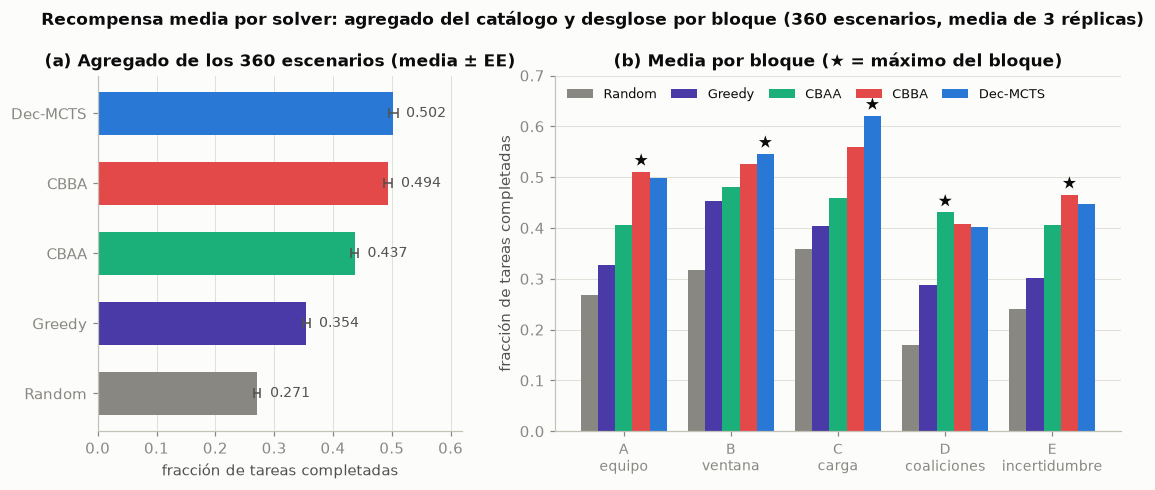

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.2),
                               gridspec_kw={'width_ratios': [1, 1.55]})

# (a) ranking global
orden = esc.groupby('solver').recompensa.mean().reindex(SOLVERS)
err   = esc.groupby('solver').recompensa.sem().reindex(SOLVERS)
ax1.barh(range(5), orden.values, height=0.62, color=[COLOR[s] for s in orden.index],
         xerr=err.values, error_kw=dict(ecolor=INK2, elinewidth=1, capsize=3))
ax1.set_yticks(range(5), [NOMBRE[s] for s in orden.index])
for i, v in enumerate(orden.values):
    ax1.text(v + 0.022, i, f'{v:.3f}', va='center', fontsize=9, color=INK2)
ax1.set_xlim(0, 0.62); ax1.set_xlabel('fracción de tareas completadas')
ax1.set_title('(a) Agregado de los 360 escenarios (media ± EE)')
ax1.grid(axis='y', visible=False)

# (b) el mismo ranking, bloque a bloque
bl = W.groupby('bloque')[SOLVERS].mean()
x = np.arange(len(bl)); w = 0.16
for k, s in enumerate(SOLVERS):
    ax2.bar(x + (k - 2) * w, bl[s].values, w, color=COLOR[s], label=NOMBRE[s])
for i, b in enumerate(bl.index):                      # marca el máximo de cada bloque
    j = SOLVERS.index(bl.loc[b].idxmax())
    ax2.text(i + (j - 2) * w, bl.loc[b].max() + 0.012, '★', ha='center',
             fontsize=11, color=INK)
ax2.set_xticks(x, [BLOQUE2[b] for b in bl.index], fontsize=9)
ax2.set_ylim(0, 0.70); ax2.set_ylabel('fracción de tareas completadas')
ax2.set_title('(b) Media por bloque (★ = máximo del bloque)')
ax2.grid(axis='x', visible=False)
ax2.legend(loc='upper left', ncol=5, fontsize=8.5, columnspacing=1.1)

fig.suptitle('Recompensa media por solver: agregado del catálogo y desglose por bloque '
             '(360 escenarios, media de 3 réplicas)',
             fontsize=11, fontweight='semibold', y=1.02, color=INK)
guardar(fig, 'p1_panorama'); plt.show()

**Resultados.** Sobre el agregado, la ordenación es
`Random` 0.271 < `Greedy` 0.354 < `CBAA` 0.437 < `CBBA` 0.494 < `Dec-MCTS` 0.502.

Las tres primeras separaciones son grandes en relación con la dispersión del conjunto: 0.083 entre
`Greedy` y `CBAA`, 0.057 entre `CBAA` y `CBBA`. **Ninguna de ellas cambia de signo en ninguno de
los cinco bloques**, ni en ninguno de los cortes por régimen del resto del cuaderno.

La cuarta separación, entre `CBBA` y `Dec-MCTS`, es de **0.009**, frente a una desviación típica
entre escenarios de **0.13–0.15**. El panel (b) muestra que el solver con media máxima cambia de
bloque en bloque: `CBBA` en A y E, `Dec-MCTS` en B y C, y `CBAA` —tercero en el agregado— en D.
Los apartados §1.2 a §1.4 cuantifican esa indeterminación y la parte 2 la desglosa por factor.

## 1.2 · Diferencia pareada entre los dos solvers de cabeza

Para los dos solvers con mayor recompensa media se calcula, en cada escenario, la diferencia
$\Delta = \text{Dec-MCTS} - \text{CBBA}$, y se resume su distribución. Al ser una diferencia
pareada, la variabilidad debida a la dificultad de cada escenario —que es la dominante— se
cancela. Se reportan la media con su error estándar entre escenarios, el estadístico $t$, el
recuento de escenarios con diferencia positiva, nula y negativa, y los cuantiles de la
distribución.

In [5]:
print('Δ pareada  Dec-MCTS − CBBA  (unidad: el escenario)')
display(pd.concat([stats_delta(W.delta).to_frame('catálogo completo').T,
                   W.groupby('regimen').delta.apply(stats_delta).unstack().reindex(REGS)]).round(4))
q = W.delta.quantile([.05, .25, .50, .75, .95]).round(3)
print(f'\nDistribución de la Δ:  mediana {q[.50]:+.3f} · rango intercuartílico '
      f'[{q[.25]:+.3f}, {q[.75]:+.3f}] · deciles extremos [{q[.05]:+.3f}, {q[.95]:+.3f}]')
print(f'En {int((W.delta.abs() < 0.02).sum())} de {len(W)} escenarios la diferencia es menor de 0.02 '
      f'(≈ una tarea de cada cincuenta).')

Δ pareada  Dec-MCTS − CBBA  (unidad: el escenario)


,Δ,EE,t,n,G,E,P
catálogo completo,0.0086,0.0040,2.1391,360.0,158.0,42.0,160.0
det,0.0201,0.0055,3.6248,162.0,76.0,30.0,56.0
lev,-0.0099,0.0153,-0.6452,18.0,4.0,3.0,11.0
est,0.0057,0.0064,0.8970,162.0,74.0,9.0,79.0
fue,-0.0497,0.0167,-2.9681,18.0,4.0,0.0,14.0



Distribución de la Δ:  mediana +0.000 · rango intercuartílico [-0.040, +0.044] · deciles extremos [-0.100, +0.149]
En 108 de 360 escenarios la diferencia es menor de 0.02 (≈ una tarea de cada cincuenta).


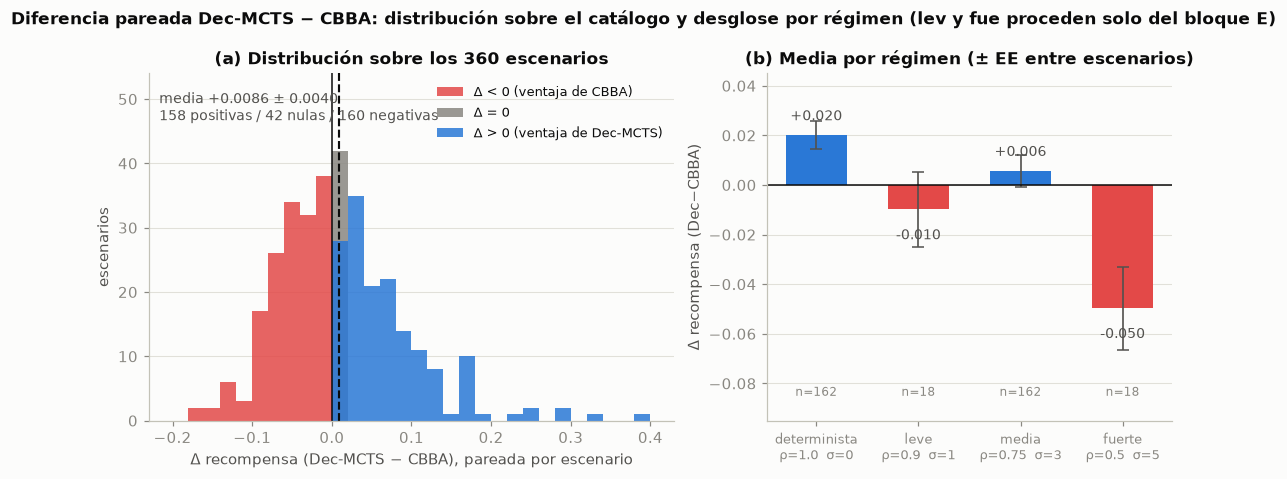

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.1),
                               gridspec_kw={'width_ratios': [1.3, 1]})

# (a) distribución de la Δ pareada
b = np.arange(-0.20, 0.42, 0.02)
ax1.hist(W.delta[W.delta < -1e-9], bins=b, color=NEG, alpha=.85, label='Δ < 0 (ventaja de CBBA)')
ax1.hist(W.delta[W.delta.abs() <= 1e-9], bins=b, color=MUTED, alpha=.85, label='Δ = 0')
ax1.hist(W.delta[W.delta > 1e-9], bins=b, color=POS, alpha=.85, label='Δ > 0 (ventaja de Dec-MCTS)')
ax1.axvline(0, color=INK, lw=1)
ax1.axvline(W.delta.mean(), color=INK, lw=1.4, ls='--')
g, e, p = int((W.delta > 1e-9).sum()), int((W.delta.abs() <= 1e-9).sum()), int((W.delta < -1e-9).sum())
ax1.text(0.02, 0.95, f'media {W.delta.mean():+.4f} ± {W.delta.sem():.4f}\n'
         f'{g} positivas / {e} nulas / {p} negativas', transform=ax1.transAxes,
         va='top', fontsize=9, color=INK2)
ax1.set_xlabel('Δ recompensa (Dec-MCTS − CBBA), pareada por escenario')
ax1.set_ylabel('escenarios'); ax1.set_ylim(0, 54)
ax1.set_title('(a) Distribución sobre los 360 escenarios')
ax1.legend(fontsize=8.5, loc='upper right'); ax1.grid(axis='x', visible=False)

# (b) Δ por régimen de incertidumbre
d = W.groupby('regimen').delta.agg(['mean', 'sem', 'count']).reindex(REGS)
col = [POS if v > 0 else NEG for v in d['mean']]
ax2.bar(range(4), d['mean'], 0.6, color=col, yerr=d['sem'],
        error_kw=dict(ecolor=INK2, elinewidth=1.1, capsize=4))
ax2.axhline(0, color=INK, lw=1)
for i, (v, n) in enumerate(zip(d['mean'], d['count'])):
    ax2.text(i, v + (0.006 if v > 0 else -0.012), f'{v:+.3f}', ha='center', fontsize=9, color=INK2)
    ax2.text(i, -0.085, f'n={n}', ha='center', fontsize=8, color=MUTED)
ax2.set_xticks(range(4), [REGIMEN[r] for r in REGS], fontsize=8.5)
ax2.set_ylim(-0.095, 0.045); ax2.set_ylabel('Δ recompensa (Dec−CBBA)')
ax2.set_title('(b) Media por régimen (± EE entre escenarios)')
ax2.grid(axis='x', visible=False)

fig.suptitle('Diferencia pareada Dec-MCTS − CBBA: distribución sobre el catálogo y desglose por régimen '
             '(lev y fue proceden solo del bloque E)',
             fontsize=11, fontweight='semibold', y=1.02, color=INK)
guardar(fig, 'p1_agregado'); plt.show()

**Resultados.** La media de la Δ sobre el catálogo completo es **+0.0086 ± 0.0040** ($t = 2.1$).
El resto de los descriptores sitúa esa media en su contexto:

- el recuento de escenarios es **158 positivos / 42 nulos / 160 negativos**;
- la **mediana de la Δ es 0.000** y el rango intercuartílico es [−0.040, +0.044];
- en **108 de los 360 escenarios** la diferencia es menor de 0.02 en valor absoluto.

Es decir: la media difiere de cero, pero la distribución subyacente está centrada en cero y es
aproximadamente simétrica, con colas de ±0.1 en ambos sentidos. El signo de la media no permite
ordenar ambos solvers para un escenario arbitrario del catálogo.

El desglose por régimen sí separa cuatro situaciones distintas:

| Régimen | Δ | $t$ | n |
|---|---|---|---|
| determinista (ρ=1, σ=0) | **+0.0201 ± 0.0055** | 3.6 | 162 |
| leve (ρ=0.9, σ=1) | −0.0099 ± 0.0153 | −0.6 | 18 |
| media (ρ=0.75, σ=3) | +0.0057 ± 0.0064 | 0.9 | 162 |
| fuerte (ρ=0.5, σ=5) | **−0.0497 ± 0.0167** | −3.0 | 18 |

La diferencia es positiva y separable de cero en régimen determinista, negativa y separable de
cero en incertidumbre fuerte, e indistinguible de cero en los dos regímenes intermedios. Los
regímenes `lev` y `fue` proceden únicamente del bloque E (18 escenarios cada uno), lo que explica
sus errores estándar; el gradiente completo se analiza en §2.5.

## 1.3 · Dominancia pareada y arrepentimiento

Los dos estadísticos de este apartado no privilegian a ninguna pareja de solvers.

- **Matriz de dominancia**: para cada par $(a, b)$, número de escenarios en que $a$ obtiene mayor
  recompensa que $b$. Los empates no se asignan a ninguno de los dos, de modo que las dos celdas
  simétricas no tienen por qué sumar 360.
- **Arrepentimiento medio**: distancia media de cada solver al **mejor solver de cada escenario**,
  $\overline{\max_s r_s - r_a}$. Cuantifica el coste esperado de fijar un único algoritmo para
  todo el catálogo sin conocer de antemano el escenario.

In [7]:
M   = esc.pivot(index='escenario', columns='solver', values='recompensa')
vic = pd.DataFrame({a: {b: int((M[a] > M[b] + 1e-9).sum()) for b in SOLVERS} for a in SOLVERS}).T
vic = vic.reindex(index=SOLVERS[::-1], columns=SOLVERS[::-1]).rename(index=NOMBRE, columns=NOMBRE)
print('Matriz de dominancia: escenarios en que la FILA supera a la COLUMNA (de 360)')
display(vic)

ganador = M[SOLVERS].idxmax(axis=1).map(NOMBRE)
arrep   = (M[SOLVERS].max(axis=1).values[:, None] - M[SOLVERS].values).mean(0)
resumen_glob = pd.DataFrame({'escenarios con la máxima recompensa': ganador.value_counts().reindex(
                                 [NOMBRE[s] for s in SOLVERS]).fillna(0).astype(int),
                             'arrepentimiento medio': np.round(arrep, 4)},
                            index=[NOMBRE[s] for s in SOLVERS])
display(resumen_glob)

Matriz de dominancia: escenarios en que la FILA supera a la COLUMNA (de 360)


,Dec-MCTS,CBBA,CBAA,Greedy,Random
Dec-MCTS,0,158,219,333,358
CBBA,160,0,209,309,349
CBAA,98,103,0,264,326
Greedy,13,24,75,0,305
Random,0,6,28,40,0


,escenarios con la máxima recompensa,arrepentimiento medio
Random,0,0.2655
Greedy,14,0.1822
CBAA,107,0.0999
CBBA,131,0.0429
Dec-MCTS,108,0.0342


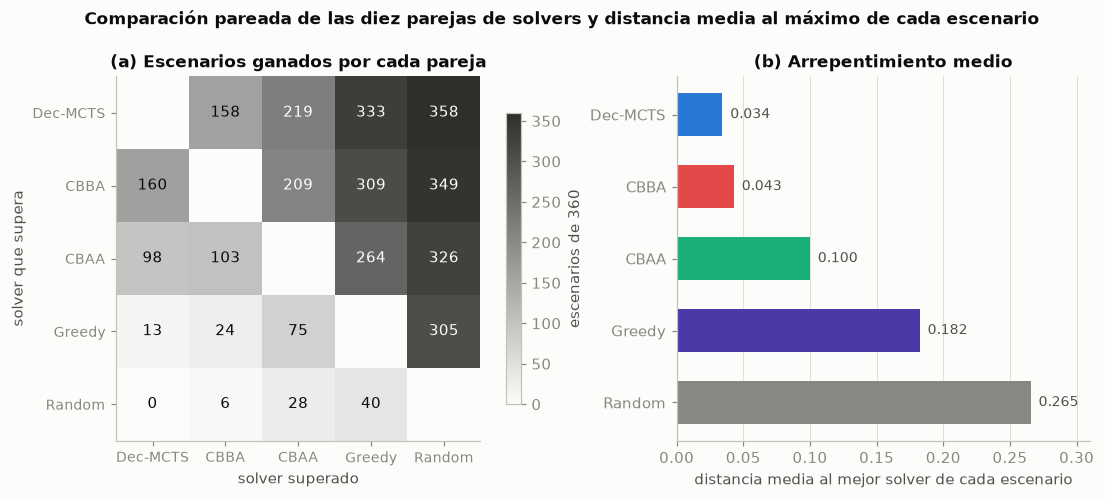

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.3),
                               gridspec_kw={'width_ratios': [1.25, 1]})

# (a) matriz de dominancia
m = vic.values.astype(float); np.fill_diagonal(m, np.nan)
im = ax1.imshow(m, cmap=SEQ, vmin=0, vmax=360)
for i in range(5):
    for j in range(5):
        if i != j:
            ax1.text(j, i, int(m[i, j]), ha='center', va='center', fontsize=9.5,
                     color='white' if m[i, j] > 200 else INK)
ax1.set_xticks(range(5), vic.columns, fontsize=9); ax1.set_yticks(range(5), vic.index, fontsize=9)
ax1.set_xlabel('solver superado'); ax1.set_ylabel('solver que supera')
ax1.set_title('(a) Escenarios ganados por cada pareja')
ax1.grid(False)
fig.colorbar(im, ax=ax1, shrink=.8, label='escenarios de 360')

# (b) arrepentimiento medio
o = np.argsort(-arrep)
ax2.barh(range(5), arrep[o], height=0.6, color=[COLOR[SOLVERS[k]] for k in o])
ax2.set_yticks(range(5), [NOMBRE[SOLVERS[k]] for k in o])
for i, k in enumerate(o):
    ax2.text(arrep[k] + 0.006, i, f'{arrep[k]:.3f}', va='center', fontsize=9, color=INK2)
ax2.set_xlim(0, 0.31); ax2.set_xlabel('distancia media al mejor solver de cada escenario')
ax2.set_title('(b) Arrepentimiento medio')
ax2.grid(axis='y', visible=False)

fig.suptitle('Comparación pareada de las diez parejas de solvers y distancia media al máximo de cada escenario',
             fontsize=11, fontweight='semibold', y=1.02, color=INK)
guardar(fig, 'p1_dominancia'); plt.show()

**Resultados.** La matriz confirma el carácter de las tres primeras separaciones del ranking:
`Dec-MCTS` supera a `Random` en 358 de 360 escenarios y a `Greedy` en 333; `CBBA` supera a `CBAA`
en 209 frente a 103. Entre `Dec-MCTS` y `CBBA` el reparto es **158 frente a 160**.

Los dos estadísticos añaden dos observaciones que la media agregada no recoge:

1. `CBAA` obtiene la **máxima recompensa en 107 escenarios**, prácticamente los mismos que
   `Dec-MCTS` (108) y no lejos de `CBBA` (131), pese a quedar 0.065 por debajo en la media global.
   Su rendimiento no está uniformemente por debajo: se concentra en un subconjunto identificable
   del catálogo, que resulta ser el bloque de coaliciones (§2.4).
2. El **arrepentimiento medio de `Dec-MCTS` (0.034) es el menor de los cinco**, por debajo del de
   `CBBA` (0.043). Obtener el máximo en menos escenarios y a la vez acumular menos pérdida
   respecto del máximo indica una distribución de diferencias más concentrada; es consistente con
   el rango intercuartílico simétrico observado en §1.2.

## 1.4 · Sensibilidad del agregado a la composición del catálogo

El agregado global es una media sobre cinco bloques que miden factores distintos. Este apartado
mide en qué grado el resultado agregado depende de esa composición, mediante dos cálculos:

- la **Δ media dentro de cada bloque**, con su error estándar;
- un análisis de sensibilidad tipo *leave-one-block-out*: la Δ global **recalculada excluyendo un
  bloque cada vez**, junto con el solver de media máxima resultante.

Los cinco bloques aportan exactamente 72 escenarios, de modo que ninguno está sobrerrepresentado
en número.

In [9]:
por_bl = panel(W, 'bloque').rename(index=BLOQUE)
print('Δ pareada Dec-MCTS − CBBA por bloque')
display(por_bl.round(3))

# Dejar fuera un bloque cada vez: ¿cuánto se mueve el agregado global?
lobo = pd.DataFrame({BLOQUE[b]: {'Δ global sin ese bloque': W[W.bloque != b].delta.mean(),
                                 'solver de media máxima': NOMBRE[W[W.bloque != b][SOLVERS].mean().idxmax()]}
                     for b in 'ABCDE'}).T
lobo.insert(0, 'Δ global (completo)', W.delta.mean())
display(lobo.round(4))

Δ pareada Dec-MCTS − CBBA por bloque


,Random,Greedy,CBAA,CBBA,Dec-MCTS,Δ,EE,t,n,G,E,P,máx.
bloque,,,,,,,,,,,,,
A · equipo,0.269,0.327,0.406,0.511,0.497,-0.013,0.006,-2.088,72.0,21.0,12.0,39.0,CBBA
B · ventana,0.317,0.452,0.480,0.525,0.546,0.021,0.007,3.086,72.0,42.0,9.0,21.0,Dec-MCTS
C · carga,0.359,0.404,0.460,0.560,0.621,0.061,0.013,4.789,72.0,47.0,2.0,23.0,Dec-MCTS
D · coaliciones,0.169,0.287,0.431,0.407,0.401,-0.006,0.007,-0.809,72.0,27.0,11.0,34.0,CBAA
E · incertidumbre,0.241,0.302,0.407,0.466,0.446,-0.019,0.007,-2.718,72.0,21.0,8.0,43.0,CBBA


,Δ global (completo),Δ global sin ese bloque,solver de media máxima
A · equipo,0.0086,0.014087,Dec-MCTS
B · ventana,0.0086,0.005529,Dec-MCTS
C · carga,0.0086,-0.004333,CBBA
D · coaliciones,0.0086,0.0123,Dec-MCTS
E · incertidumbre,0.0086,0.015599,Dec-MCTS


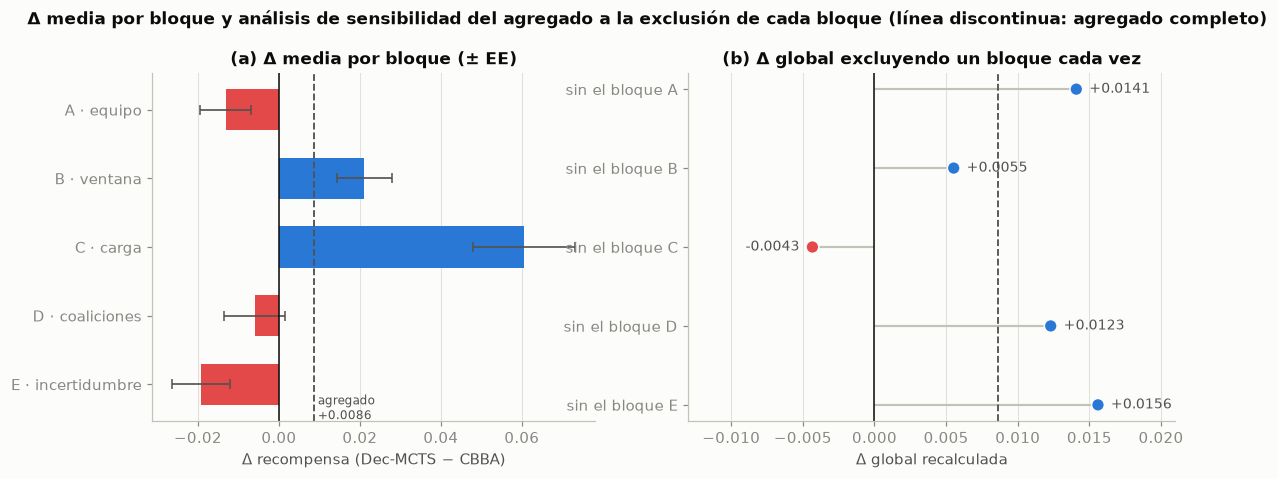

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.1), gridspec_kw={'width_ratios': [1, 1.1]})

# (a) Δ por bloque
d = W.groupby('bloque').delta.agg(['mean', 'sem'])
y = np.arange(len(d))
ax1.barh(y, d['mean'], 0.6, color=[POS if v > 0 else NEG for v in d['mean']],
         xerr=d['sem'], error_kw=dict(ecolor=INK2, elinewidth=1.1, capsize=3))
ax1.axvline(0, color=INK, lw=1)
ax1.axvline(W.delta.mean(), color=INK2, lw=1.2, ls='--')
ax1.text(W.delta.mean(), 4.35, f' agregado\n {W.delta.mean():+.4f}', fontsize=8, color=INK2, va='center')
ax1.set_yticks(y, [BLOQUE[b] for b in d.index]); ax1.invert_yaxis()
ax1.set_xlabel('Δ recompensa (Dec-MCTS − CBBA)')
ax1.set_title('(a) Δ media por bloque (± EE)'); ax1.grid(axis='y', visible=False)

# (b) leave-one-block-out del agregado
vals = [W[W.bloque != b].delta.mean() for b in 'ABCDE']
ax2.hlines(range(5), 0, vals, color=AXIS, lw=1.4)
ax2.scatter(vals, range(5), s=70, zorder=3,
            color=[POS if v > 0 else NEG for v in vals], edgecolor=SURFACE, linewidth=1)
ax2.axvline(0, color=INK, lw=1)
ax2.axvline(W.delta.mean(), color=INK2, lw=1.2, ls='--')
for i, v in enumerate(vals):
    ax2.text(v + (0.0009 if v > 0 else -0.0009), i, f'{v:+.4f}',
             va='center', ha='left' if v > 0 else 'right', fontsize=9, color=INK2)
ax2.set_yticks(range(5), [f'sin el bloque {b}' for b in 'ABCDE']); ax2.invert_yaxis()
ax2.set_xlim(-0.013, 0.021); ax2.set_xlabel('Δ global recalculada')
ax2.set_title('(b) Δ global excluyendo un bloque cada vez')
ax2.grid(axis='y', visible=False)

fig.suptitle('Δ media por bloque y análisis de sensibilidad del agregado a la exclusión de cada bloque '
             '(línea discontinua: agregado completo)',
             fontsize=11, fontweight='semibold', y=1.02, color=INK)
guardar(fig, 'p1_composicion'); plt.show()

**Resultados.** Las Δ por bloque no coinciden en signo: C **+0.061 ± 0.013**, B **+0.021 ± 0.007**,
D −0.006 ± 0.007, A −0.013 ± 0.006, E −0.019 ± 0.007. El agregado (+0.0086) es la media de esas
cinco cantidades.

El análisis de sensibilidad da:

| Conjunto | Δ global | Solver de media máxima |
|---|---|---|
| catálogo completo | +0.0086 | Dec-MCTS |
| sin el bloque A | +0.0141 | Dec-MCTS |
| sin el bloque B | +0.0055 | Dec-MCTS |
| **sin el bloque C** | **−0.0043** | **CBBA** |
| sin el bloque D | +0.0123 | Dec-MCTS |
| sin el bloque E | +0.0156 | Dec-MCTS |

**Excluir el bloque C invierte el signo del agregado y el orden de los dos primeros solvers.** La
inversión no procede de un desequilibrio en el número de escenarios —los cinco bloques aportan
72—, sino de qué factores se decidió barrer y con qué niveles.

Esta sensibilidad tiene una consecuencia metodológica que conviene declarar junto con los
resultados: **el signo del agregado de este catálogo no es una propiedad invariante de los
algoritmos, sino del conjunto de prueba**. Una auditoría *a posteriori* de la composición muestra
que dos de los tres niveles del bloque B (ventanas `P` y `C`) y dos de los tres del bloque C
(cargas L=3 y L=4) caen en la región donde la Δ es positiva, mientras que A, D y E caen
mayoritariamente en la región donde es negativa. Los niveles se fijaron antes de medir, pero el
resultado agregado depende de ellos.

---

# Parte 2 · Análisis por bloque

Cada bloque aísla **un solo factor** sobre la configuración de referencia (L = 6, ventana
estrecha, $q_j = 1$, horizonte T = 40), que es la del **bloque A**. Los bloques B, C y D varían ese
factor sobre $n \in \{2,5,10\}$ (D usa $\{3,6,10\}$) y se comparan **contra las celdas de A a esos
mismos $n$**, generadas con la misma semilla: misma geometría, mismos plazos y mismos sorteos. El
pareado es por tanto exacto y el contraste mide el efecto del factor, no la diferencia entre dos
muestras independientes.

| Bloque | Factor barrido | Niveles | Control |
|---|---|---|---|
| **A** | tamaño del equipo | $n = 2 \dots 10$ | — (es el control) |
| **B** | forma de la ventana | `P` solo plazo · `C` plazo escalonado · `A` ancha | `E` estrecha (A) |
| **C** | carga por robot | $L = 3, 4, 8$ | $L = 6$ (A) |
| **D** | coaliciones | `q2` dos trabajadores · `qm` mezcla 1-2-3 | `q1` (A) |
| **E** | incertidumbre | $\rho = 1.0, 0.9, 0.75, 0.5$ | `det` es un extremo del propio gradiente |

Cada apartado reporta las mismas magnitudes: recompensa media de los cinco solvers, Δ pareada con
su error estándar y recuento de escenarios, y —cuando el factor lo permite— el contraste frente al
control.

In [11]:
print('Resumen por bloque — recompensa media de los cinco solvers y Δ pareada Dec-MCTS − CBBA')
display(panel(W, 'bloque').rename(index=BLOQUE).round(3))
print('\nEl mismo desglose separando régimen determinista de estocástico:')
display(panel(W, ['bloque', 'regimen']).rename(index=BLOQUE).round(3))

Resumen por bloque — recompensa media de los cinco solvers y Δ pareada Dec-MCTS − CBBA


,Random,Greedy,CBAA,CBBA,Dec-MCTS,Δ,EE,t,n,G,E,P,máx.
bloque,,,,,,,,,,,,,
A · equipo,0.269,0.327,0.406,0.511,0.497,-0.013,0.006,-2.088,72.0,21.0,12.0,39.0,CBBA
B · ventana,0.317,0.452,0.480,0.525,0.546,0.021,0.007,3.086,72.0,42.0,9.0,21.0,Dec-MCTS
C · carga,0.359,0.404,0.460,0.560,0.621,0.061,0.013,4.789,72.0,47.0,2.0,23.0,Dec-MCTS
D · coaliciones,0.169,0.287,0.431,0.407,0.401,-0.006,0.007,-0.809,72.0,27.0,11.0,34.0,CBAA
E · incertidumbre,0.241,0.302,0.407,0.466,0.446,-0.019,0.007,-2.718,72.0,21.0,8.0,43.0,CBBA



El mismo desglose separando régimen determinista de estocástico:


Random  Greedy   CBAA   CBBA  Dec-MCTS      Δ  \
bloque            regimen                                                  
A · equipo        det       0.296   0.368  0.488  0.576     0.577  0.000   
                  est       0.241   0.285  0.325  0.445     0.418 -0.027   
B · ventana       det       0.347   0.499  0.514  0.572     0.600  0.027   
                  est       0.287   0.406  0.447  0.477     0.492  0.015   
C · carga         det       0.398   0.452  0.545  0.639     0.713  0.074   
                  est       0.320   0.356  0.374  0.481     0.529  0.047   
D · coaliciones   det       0.196   0.309  0.495  0.472     0.457 -0.015   
                  est       0.142   0.265  0.366  0.343     0.345  0.003   
E · incertidumbre det       0.302   0.365  0.524  0.563     0.570  0.007   
                  est       0.241   0.295  0.369  0.452     0.428 -0.024   
                  fue       0.162   0.207  0.263  0.328     0.278 -0.050   
                  lev       0.261   0.340  0.471  0.520     0.510 -0.010   

                              EE      t     n     G    E     P      máx.  
bloque            regimen                                                 
A · equipo        det      0.006  0.074  36.0  12.0  9.0  15.0  Dec-MCTS  
                  est      0.011 -2.474  36.0   9.0  3.0  24.0      CBBA  
B · ventana       det      0.010  2.667  36.0  20.0  9.0   7.0  Dec-MCTS  
                  est      0.009  1.633  36.0  22.0  0.0  14.0  Dec-MCTS  
C · carga         det      0.015  4.952  36.0  26.0  1.0   9.0  Dec-MCTS  
                  est      0.020  2.317  36.0  21.0  1.0  14.0  Dec-MCTS  
D · coaliciones   det      0.011 -1.280  36.0  12.0  6.0  18.0      CBAA  
                  est      0.009  0.271  36.0  15.0  5.0  16.0      CBAA  
E · incertidumbre det      0.007  0.940  18.0   6.0  5.0   7.0  Dec-MCTS  
                  est      0.013 -1.864  18.0   7.0  0.0  11.0      CBBA  
                  fue      0.017 -2.968  18.0   4.0  0.0  14.0      CBBA  
                  lev      0.015 -0.645  18.0   4.0  3.0  11.0      CBBA

## 2.1 · Bloque A — tamaño del equipo a iso-dificultad

Nueve tamaños de equipo ($n = 2 \dots 10$) con **carga por robot constante** $L = 6$ y horizonte
fijo $T = 40$. El número de tareas crece proporcionalmente al número de robots, de modo que
aumentar $n$ no reduce el trabajo asignado a cada robot: el factor queda aislado del nivel de
dificultad. El estadístico del bloque es la **pendiente OLS de la recompensa frente al tamaño del equipo $n$**, por
solver y por régimen, y la pendiente de la propia Δ.

In [12]:
A = W[W.bloque == 'A']

def pendiente(x, y):
    '''Pendiente OLS y su estadístico t.'''
    x, y = np.asarray(x, float), np.asarray(y, float)
    b, a = np.polyfit(x, y, 1)
    r = y - (a + b * x)
    se = np.sqrt((r ** 2).sum() / (len(x) - 2) / ((x - x.mean()) ** 2).sum())
    return b, b / se

print('Recompensa media frente al nº de robots (carga por robot constante, L=6)')
display(A.groupby(['regimen', 'robots'])[SOLVERS + ['delta']].mean()
         .rename(columns=NOMBRE).round(3))

print('\nPendiente por robot adicional (OLS sobre los 36 escenarios de cada régimen)')
pend = pd.DataFrame({NOMBRE[s]: {r: '{:+.4f} (t={:.1f})'.format(*pendiente(A[A.regimen == r].robots,
                                                                          A[A.regimen == r][s]))
                                 for r in ('det', 'est')} for s in SOLVERS})
pend['Δ  (Dec − CBBA)'] = {r: '{:+.4f} (t={:.1f})'.format(*pendiente(A[A.regimen == r].robots,
                                                                    A[A.regimen == r].delta))
                           for r in ('det', 'est')}
display(pend)

Recompensa media frente al nº de robots (carga por robot constante, L=6)


Random  Greedy   CBAA   CBBA  Dec-MCTS  delta
regimen robots                                               
det     2        0.326   0.354  0.542  0.500     0.521  0.021
        3        0.273   0.361  0.472  0.514     0.528  0.014
        4        0.292   0.354  0.490  0.552     0.556  0.003
        5        0.317   0.375  0.508  0.569     0.581  0.011
        6        0.280   0.354  0.391  0.583     0.574 -0.009
        7        0.298   0.359  0.482  0.601     0.607  0.006
        8        0.286   0.396  0.557  0.625     0.611 -0.014
        9        0.284   0.412  0.440  0.611     0.593 -0.019
        10       0.310   0.350  0.508  0.629     0.619 -0.010
est     2        0.257   0.299  0.389  0.340     0.410  0.069
        3        0.245   0.273  0.287  0.370     0.398  0.028
        4        0.229   0.250  0.288  0.441     0.399 -0.042
        5        0.250   0.294  0.378  0.450     0.428 -0.022
        6        0.231   0.280  0.271  0.426     0.398 -0.028
        7        0.228   0.276  0.349  0.486     0.450 -0.036
        8        0.238   0.292  0.344  0.497     0.432 -0.064
        9        0.250   0.319  0.278  0.489     0.414 -0.076
        10       0.244   0.282  0.337  0.507     0.436 -0.071


Pendiente por robot adicional (OLS sobre los 36 escenarios de cada régimen)


,Random,Greedy,CBAA,CBBA,Dec-MCTS,Δ (Dec − CBBA)
det,-0.0011 (t=-0.5),+0.0034 (t=1.0),-0.0020 (t=-0.4),+0.0164 (t=6.6),+0.0121 (t=7.7),-0.0043 (t=-2.0)
est,-0.0007 (t=-0.4),+0.0023 (t=1.1),-0.0025 (t=-0.5),+0.0195 (t=6.6),+0.0040 (t=1.5),-0.0155 (t=-4.7)


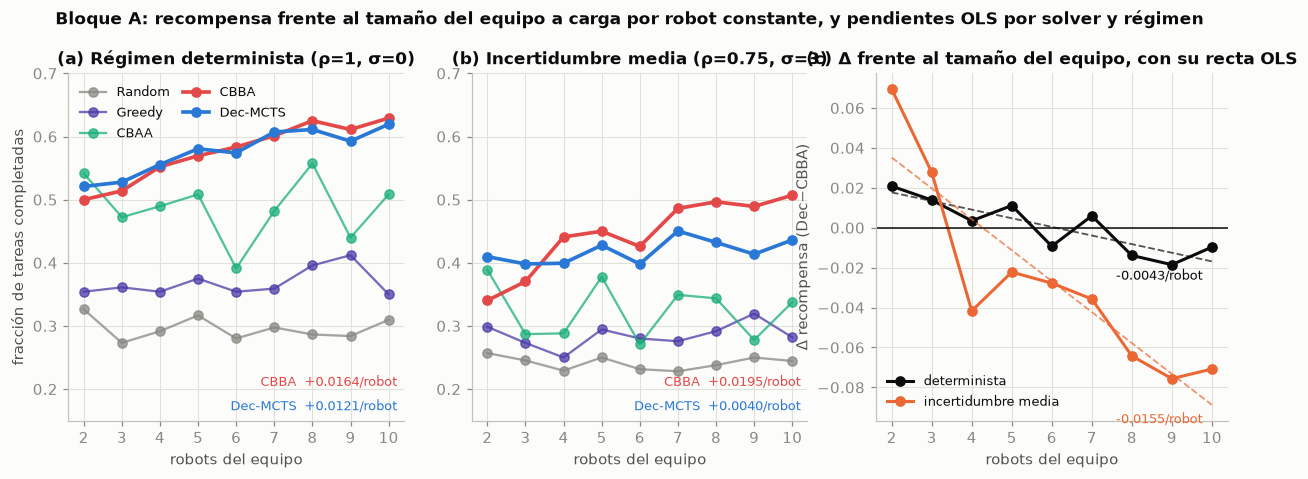

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(13.6, 4.1), gridspec_kw={'width_ratios': [1, 1, 1.05]})

for ax, reg, tit in zip(axes[:2], ('det', 'est'),
                        ('(a) Régimen determinista (ρ=1, σ=0)',
                         '(b) Incertidumbre media (ρ=0.75, σ=3)')):
    s = A[A.regimen == reg]
    for sol in SOLVERS:
        y = s.groupby('robots')[sol].mean()
        ax.plot(y.index, y.values, marker='o', color=COLOR[sol], label=NOMBRE[sol],
                lw=2.4 if sol in (DEC, REF) else 1.5,
                zorder=3 if sol in (DEC, REF) else 2, alpha=1 if sol in (DEC, REF) else .75)
    for k, sol in enumerate((REF, DEC)):                 # pendientes OLS, en una esquina libre
        b, _ = pendiente(s.robots, s[sol])
        ax.text(0.98, 0.10 - 0.07 * k, f'{NOMBRE[sol]}  {b:+.4f}/robot', transform=ax.transAxes,
                ha='right', fontsize=8.5, color=COLOR[sol])
    ax.set_xlabel('robots del equipo'); ax.set_ylim(0.15, 0.70); ax.set_title(tit)
    ax.set_xticks(range(2, 11))
axes[0].set_ylabel('fracción de tareas completadas')
axes[0].legend(loc='upper left', fontsize=8.5, ncol=2, columnspacing=1)

# (c) la Δ frente al tamaño del equipo
ax = axes[2]
for reg, lab in (('det', 'determinista'), ('est', 'incertidumbre media')):
    s = A[A.regimen == reg]
    y = s.groupby('robots').delta.mean()
    ax.plot(y.index, y.values, marker='o', color=C_REG[reg], label=lab, lw=2)
    b, a = np.polyfit(s.robots, s.delta, 1)
    xs = np.array([2, 10]); ax.plot(xs, a + b * xs, color=C_REG[reg], ls='--', lw=1.2, alpha=.7)
    ax.annotate(f'{b:+.4f}/robot', (10, a + b * 10), xytext=(-6, -12),
                textcoords='offset points', ha='right', fontsize=8.5, color=C_REG[reg])
ax.axhline(0, color=INK, lw=1)
ax.set_xticks(range(2, 11)); ax.set_xlabel('robots del equipo')
ax.set_ylabel('Δ recompensa (Dec−CBBA)')
ax.set_title('(c) Δ frente al tamaño del equipo, con su recta OLS'); ax.legend(fontsize=8.5, loc='lower left')

fig.suptitle('Bloque A: recompensa frente al tamaño del equipo a carga por robot constante, '
             'y pendientes OLS por solver y régimen',
             fontsize=11, fontweight='semibold', y=1.02, color=INK)
guardar(fig, 'p2_A_escalado'); plt.show()

**Resultados.** Las pendientes por robot adicional son:

| | `Random` | `Greedy` | `CBAA` | `CBBA` | `Dec-MCTS` | Δ (Dec − CBBA) |
|---|---|---|---|---|---|---|
| determinista | −0.0011 (t=−0.5) | +0.0034 (t=1.0) | −0.0020 (t=−0.4) | **+0.0164 (t=6.6)** | **+0.0121 (t=7.7)** | −0.0043 (t=−2.0) |
| incertidumbre media | −0.0007 (t=−0.4) | +0.0023 (t=1.1) | −0.0025 (t=−0.5) | **+0.0195 (t=6.6)** | +0.0040 (t=1.5) | **−0.0155 (t=−4.7)** |

Tres lecturas directas:

1. **`Random`, `Greedy` y `CBAA` no convierten robots adicionales en recompensa** en ninguno de
   los dos regímenes: sus pendientes no se distinguen de cero. `CBAA`, que es una subasta de tarea
   única, se comporta como las heurísticas sin comunicación en este contraste.
2. **En régimen determinista, `CBBA` y `Dec-MCTS` sí escalan**, con pendientes de +0.0164 y
   +0.0121 y estadísticos $t$ de 6.6 y 7.7 respectivamente.
3. **Bajo incertidumbre las dos pendientes se separan**: la de `CBBA` se mantiene (+0.0195,
   $t$ = 6.6) y la de `Dec-MCTS` cae a +0.0040 con $t = 1.5$, es decir, no se distingue de cero.
   La pendiente de la propia Δ es **−0.0155 por robot ($t = −4.7$)**: la diferencia pasa de +0.069
   con 2 robots a −0.071 con 10. En determinista esa pendiente es −0.0043 ($t = −2.0$), tres veces
   menor.

*Interpretación (hipótesis, no contrastada en este cuaderno)*: el comportamiento es compatible con
un exceso de deconflicción en Dec-MCTS. El solver cede las tareas que estima cubiertas por un
vecino a partir del plan que este ha comunicado; si la incertidumbre invalida ese plan, la
estimación falla, y el número de vecinos sobre los que se condiciona crece con el tamaño del
equipo. Esto predice a la vez el signo del efecto, su dependencia del régimen y su crecimiento
lineal con el tamaño del equipo, pero el cuaderno solo mide la asociación, no el mecanismo.

## 2.2 · Bloque B — forma de la ventana de ejecución

Tres formas alternativas de la ventana $[t_j^s, t_j^l]$ frente a la estrecha del control, con el
mismo equipo y la misma carga: `P` elimina la **espera** conservando el plazo, `C` sustituye el
plazo por uno **escalonado** que no depende de $t_j^s$, y `A` amplía la ventana. Además de los
niveles absolutos se reporta el **efecto sobre la Δ**, pareado escenario a escenario contra su
homólogo con ventana `E` (misma semilla, misma geometría, mismos sorteos).

Nota sobre el diseño, relevante para interpretar el nivel `C`: la ventana escalonada resulta
**~5 unidades más apretada** que la de solo plazo (plazo medio 24.67 frente a 29.67; la estrecha
29.97 y la ancha 49.87), porque el margen nominal de +10 que heredan las otras tres no se aplica a
una ventana cuyo plazo no depende de $t_0$. Es una propiedad deliberada del generador, no un
sesgo introducido a posteriori, pero hace que `C` no sea solo «otra forma» sino también «algo más
exigente».

In [14]:
B    = W[W.bloque == 'B']
ctrl = A[(A.robots.isin([2, 5, 10])) & (A.instancia <= 4)]          # control pareado exacto
comb = pd.concat([ctrl.assign(ventana='E'), B])

print('Recompensa media y Δ pareada por forma de ventana (E = control del bloque A)')
display(comb.groupby(['regimen', 'ventana'], observed=True).apply(fila, include_groups=False)
            .reindex([(r, v) for r in ('det', 'est') for v in ('E', 'P', 'C', 'A')]).round(3))

# Efecto del cambio de ventana sobre la Δ, pareado escenario a escenario contra su control
llave = lambda d: list(zip(d.robots, d.regimen, d.instancia))
base  = pd.Series(ctrl.delta.values, index=llave(ctrl))
print('\nEfecto de cambiar la ventana sobre la Δ (pareado contra el mismo escenario con ventana E)')
ef = {}
for v in ('P', 'C', 'A'):
    for r in ('det', 'est'):
        s = B[(B.ventana == v) & (B.regimen == r)]
        dd = s.delta.values - base.loc[llave(s)].values
        ef[(VENTANA[v].replace('\n', ' '), r)] = {'efecto sobre la Δ': dd.mean(),
                                                  'EE': pd.Series(dd).sem(), 'n': len(dd)}
display(pd.DataFrame(ef).T.round(4))

Recompensa media y Δ pareada por forma de ventana (E = control del bloque A)


Random  Greedy   CBAA   CBBA  Dec-MCTS      Δ     EE      t  \
regimen ventana                                                                
det     E         0.318   0.360  0.519  0.566     0.574  0.007  0.009  0.783   
        P         0.348   0.501  0.559  0.560     0.598  0.038  0.014  2.700   
        C         0.347   0.442  0.457  0.455     0.533  0.078  0.010  7.654   
        A         0.346   0.556  0.525  0.703     0.669 -0.034  0.011 -3.022   
est     E         0.250   0.292  0.368  0.432     0.425 -0.008  0.024 -0.333   
        P         0.284   0.406  0.436  0.444     0.464  0.021  0.012  1.719   
        C         0.286   0.370  0.419  0.417     0.447  0.030  0.017  1.723   
        A         0.293   0.441  0.486  0.572     0.565 -0.007  0.016 -0.439   

                    n     G    E    P      máx.  
regimen ventana                                  
det     E        12.0   5.0  4.0  3.0  Dec-MCTS  
        P        12.0   8.0  3.0  1.0  Dec-MCTS  
        C        12.0  12.0  0.0  0.0  Dec-MCTS  
        A        12.0   0.0  6.0  6.0      CBBA  
est     E        12.0   4.0  2.0  6.0      CBBA  
        P        12.0   8.0  0.0  4.0  Dec-MCTS  
        C        12.0   8.0  0.0  4.0  Dec-MCTS  
        A        12.0   6.0  0.0  6.0      CBBA


Efecto de cambiar la ventana sobre la Δ (pareado contra el mismo escenario con ventana E)


efecto sobre la Δ      EE     n
P · solo plazo (sin espera) det             0.0306  0.0111  12.0
                            est             0.0287  0.0182  12.0
C · plazo escalonado        det             0.0708  0.0131  12.0
                            est             0.0380  0.0290  12.0
A · ancha                   det            -0.0412  0.0110  12.0
                            est             0.0009  0.0205  12.0

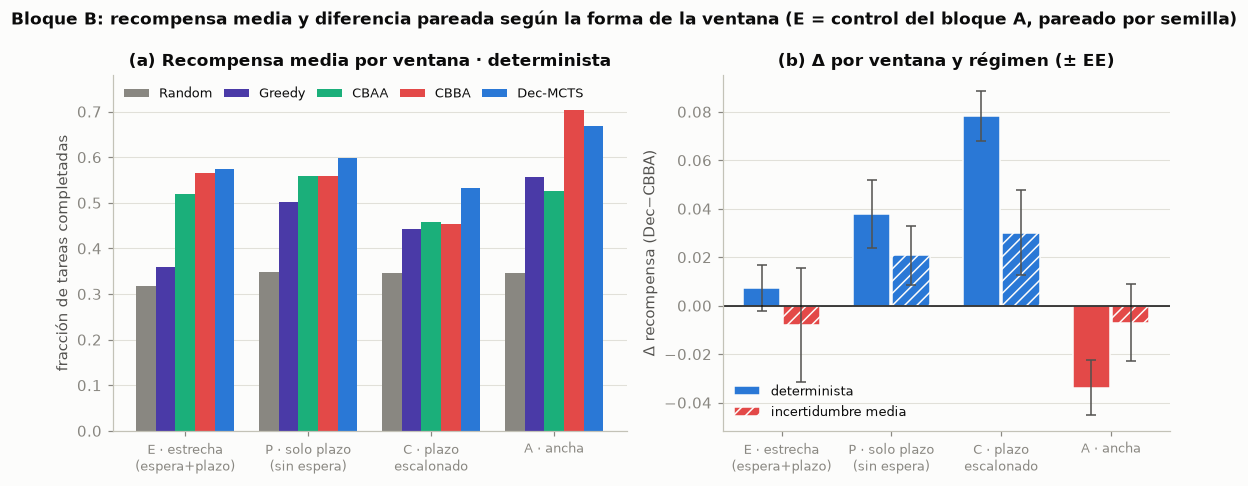

In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.4, 4.2), gridspec_kw={'width_ratios': [1.15, 1]})

ords = ['E', 'P', 'C', 'A']
# (a) niveles de los cinco solvers por ventana, régimen determinista
sub = comb[comb.regimen == 'det'].groupby('ventana', observed=True)[SOLVERS].mean().reindex(ords)
x, w = np.arange(4), 0.16
for k, s in enumerate(SOLVERS):
    ax1.bar(x + (k - 2) * w, sub[s].values, w, color=COLOR[s], label=NOMBRE[s])
ax1.set_xticks(x, [VENTANA[v] for v in ords], fontsize=8.5)
ax1.set_ylabel('fracción de tareas completadas'); ax1.set_ylim(0, 0.78)
ax1.set_title('(a) Recompensa media por ventana · determinista')
ax1.legend(ncol=5, fontsize=8.2, loc='upper left', columnspacing=.9)
ax1.grid(axis='x', visible=False)

# (b) Δ por ventana y régimen
for j, (reg, hatch, lab) in enumerate((('det', None, 'determinista'), ('est', '///', 'incertidumbre media'))):
    d = comb[comb.regimen == reg].groupby('ventana', observed=True).delta.agg(['mean', 'sem']).reindex(ords)
    ax2.bar(x + (j - 0.5) * 0.36, d['mean'], 0.34, yerr=d['sem'], hatch=hatch, label=lab,
            color=[POS if v > 0 else NEG for v in d['mean']], edgecolor=SURFACE,
            error_kw=dict(ecolor=INK2, elinewidth=1, capsize=3))
ax2.axhline(0, color=INK, lw=1)
ax2.set_xticks(x, [VENTANA[v] for v in ords], fontsize=8.5)
ax2.set_ylabel('Δ recompensa (Dec−CBBA)')
ax2.set_title('(b) Δ por ventana y régimen (± EE)')
ax2.legend(fontsize=8.5, loc='lower left'); ax2.grid(axis='x', visible=False)

fig.suptitle('Bloque B: recompensa media y diferencia pareada según la forma de la ventana '
             '(E = control del bloque A, pareado por semilla)',
             fontsize=11, fontweight='semibold', y=1.02, color=INK)
guardar(fig, 'p2_B_ventana'); plt.show()

**Resultados.** Δ pareada por ventana, con el recuento de escenarios entre paréntesis:

| Ventana | determinista | incertidumbre media |
|---|---|---|
| `E` estrecha (control) | +0.007 ± 0.010 (5/4/3) | −0.008 ± 0.024 (4/2/6) |
| `P` solo plazo | +0.038 ± 0.014 (8/3/1) | +0.021 ± 0.012 (8/0/4) |
| `C` plazo escalonado | **+0.078 ± 0.010 (12/0/0)** | +0.030 ± 0.017 (8/0/4) |
| `A` ancha | **−0.034 ± 0.011 (0/6/6)** | −0.007 ± 0.016 (6/0/6) |

Los dos extremos son los niveles `C` y `A`, y el efecto pareado contra el control lo confirma:
cambiar `E` por `C` mueve la Δ en **+0.071 ± 0.013** en determinista, y cambiar `E` por `A` la
mueve en **−0.041 ± 0.011**. Eliminar la espera (`P`) la mueve en +0.031 ± 0.011.

En el nivel `C` y en régimen determinista, `Dec-MCTS` obtiene la media más alta de los cinco
solvers (0.533 frente a 0.455 de `CBBA`) y la diferencia es positiva en los 12 escenarios. En el
nivel `A`, `CBBA` obtiene la media más alta (0.703 frente a 0.669) y la diferencia no es positiva
en ninguno de los 12.

*Interpretación (hipótesis)*: los dos niveles se distinguen por cuánta estructura temporal contiene
el problema. Con plazos heterogéneos e independientes del instante de apertura, el **orden** de
ejecución condiciona el resultado; con ventanas holgadas el problema se aproxima a uno de reparto,
donde el orden importa menos. La ventaja relativa de una búsqueda sobre secuencias frente a una
subasta sobre precios se ordena igual que esa gradación, pero el bloque mide la asociación, no la
causa. Recuérdese además que `C` es también algo más exigente que `P` (nota de diseño, arriba).

## 2.3 · Bloque C — carga por robot

La carga por robot $L = \sum_j q_j / R$ es el parámetro con el que el catálogo controla la
dificultad: con horizonte fijo, $L = 3$ deja holgura y $L = 8$ satura. El bloque barre
$L \in \{3, 4, 8\}$ sobre $n \in \{2, 5, 10\}$ y, junto con el control $L = 6$ del bloque A, forma
una **rejilla completa robots × carga** que permite separar los dos factores.

⚠️ A diferencia de B y D, el pareado aquí **no es exacto**: cambiar $L$ cambia el número de tareas
$n$, de modo que las celdas comparadas son escenarios distintos, no el mismo escenario con otro
parámetro.

In [16]:
Cb   = W[W.bloque == 'C']
grid = pd.concat([Cb, ctrl])           # ctrl aporta la columna L=6 (bloque A, R ∈ {2,5,10})

print('Recompensa media por carga por robot')
display(grid.groupby(['regimen', 'carga'])[SOLVERS].mean()
            .rename(columns=NOMBRE).reindex([(r, l) for r in ('det', 'est') for l in (3, 4, 6, 8)])
            .round(3))
print('\nΔ pareada Dec-MCTS − CBBA en la rejilla robots × carga')
display(grid.pivot_table(index='robots', columns=['regimen', 'carga'], values='delta').round(3))

Recompensa media por carga por robot


Random  Greedy   CBAA   CBBA  Dec-MCTS
regimen carga                                        
det     3       0.531   0.589  0.608  0.800     0.930
        4       0.426   0.477  0.574  0.677     0.757
        6       0.318   0.360  0.519  0.566     0.574
        8       0.236   0.289  0.453  0.440     0.451
est     3       0.431   0.481  0.409  0.553     0.674
        4       0.342   0.362  0.388  0.515     0.588
        6       0.250   0.292  0.368  0.432     0.425
        8       0.188   0.224  0.325  0.376     0.324


Δ pareada Dec-MCTS − CBBA en la rejilla robots × carga


regimen    det                         est                     
carga        3      4      6      8      3      4      6      8
robots                                                         
2        0.208  0.167  0.021  0.078  0.167  0.135  0.069 -0.021
5        0.100  0.067  0.011 -0.006  0.156  0.104 -0.022 -0.056
10       0.081  0.006 -0.010 -0.036  0.042 -0.021 -0.071 -0.080

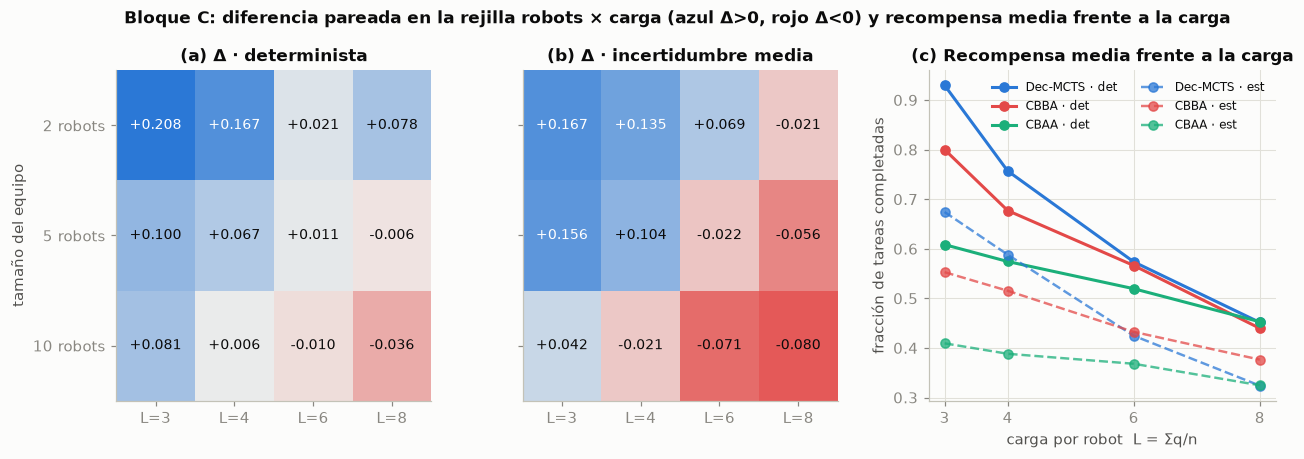

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(13.6, 3.9), gridspec_kw={'width_ratios': [1, 1, 1.1],
                                                                 'wspace': 0.28})
Ls, Rs = [3, 4, 6, 8], [2, 5, 10]

for k, (ax, reg, tit) in enumerate(zip(axes[:2], ('det', 'est'),
                                       ('(a) Δ · determinista', '(b) Δ · incertidumbre media'))):
    m = grid[grid.regimen == reg].pivot_table(index='robots', columns='carga', values='delta')
    m = m.reindex(index=Rs, columns=Ls)
    ax.imshow(m.values, cmap=DIV, aspect='auto',
              norm=TwoSlopeNorm(vmin=-0.09, vcenter=0, vmax=0.21))
    for i in range(3):
        for j in range(4):
            ax.text(j, i, f'{m.values[i, j]:+.3f}', ha='center', va='center', fontsize=9,
                    color='white' if abs(m.values[i, j]) > 0.13 else INK)
    ax.set_xticks(range(4), [f'L={l}' for l in Ls])
    ax.set_yticks(range(3), [f'{r} robots' for r in Rs] if k == 0 else [''] * 3)
    ax.set_title(tit); ax.grid(False)
axes[0].set_ylabel('tamaño del equipo')

# (c) niveles frente a la carga
ax = axes[2]
for reg, ls in (('det', '-'), ('est', '--')):
    for s in (DEC, REF, 'cbaa'):
        y = grid[grid.regimen == reg].groupby('carga')[s].mean().reindex(Ls)
        ax.plot(Ls, y.values, ls, marker='o', color=COLOR[s], lw=2 if ls == '-' else 1.6,
                label=f'{NOMBRE[s]} · {reg}', alpha=1 if ls == '-' else .75)
ax.set_xticks(Ls); ax.set_xlabel('carga por robot  L = Σq/n')
ax.set_ylabel('fracción de tareas completadas')
ax.set_title('(c) Recompensa media frente a la carga'); ax.legend(fontsize=7.8, ncol=2, loc='upper right')

fig.suptitle('Bloque C: diferencia pareada en la rejilla robots × carga (azul Δ>0, rojo Δ<0) '
             'y recompensa media frente a la carga',
             fontsize=11, fontweight='semibold', y=1.02, color=INK)
guardar(fig, 'p2_C_carga'); plt.show()

**Resultados.** Es el bloque con mayor Δ media (+0.061 ± 0.013) y el que presenta el gradiente más
regular del catálogo: la rejilla decrece **en los dos ejes a la vez** —al aumentar la carga y al
aumentar el número de robots— con **una sola excepción** entre las 24 celdas (2 robots, L=8,
determinista: +0.078 frente a +0.021 de L=6). Los extremos son **+0.208** (2 robots, L=3,
determinista) y **−0.080** (10 robots, L=8, incertidumbre media).

En niveles absolutos, con $L=3$ y régimen determinista `Dec-MCTS` obtiene 0.930 frente a 0.800 de
`CBBA`; con $L=8$ las medias se aproximan (0.451 frente a 0.440) y bajo incertidumbre se invierten
(0.324 frente a 0.376).

*Interpretación (hipótesis)*: al saturar, una fracción creciente de la recompensa disponible se
pierde por falta de tiempo con independencia de la asignación, lo que reduce el margen en que
cualquier política puede diferenciarse; con holgura, en cambio, el orden de ejecución es el
factor que queda por optimizar.

⚠️ **Este bloque es el que determina el signo del agregado** (§1.4): es el único cuya exclusión lo
invierte, y dos de sus tres niveles ($L=3$ y $L=4$) caen en la región de Δ positiva.

## 2.4 · Bloque D — coaliciones

Único bloque en que una tarea requiere **varios robots simultáneamente** ($q_j > 1$): `q2` exige
dos trabajadores en todas las tareas y `qm` mezcla requisitos de 1, 2 y 3 manteniendo
$\bar q = 2$. La carga por robot se mantiene en $L = 6$ reajustando el número de tareas
($m = Ln/\bar q$), de modo que el trabajo total coincide con el del control y el único factor que
cambia es la necesidad de sincronización.

In [18]:
D     = W[W.bloque == 'D']
ctrlD = A[A.robots.isin([3, 6, 10])]                       # control q1 a los mismos R
combD = pd.concat([ctrlD.assign(coalicion='q1'), D])

print('Recompensa media por tipo de coalición (q1 = control del bloque A)')
display(combD.groupby(['regimen', 'coalicion'], observed=True).apply(fila, include_groups=False)
             .reindex([(r, q) for r in ('det', 'est') for q in ('q1', 'q2', 'qm')]).round(3))
print('\nEl bloque completo:')
display(panel(D).round(3))
print('\nΔ por tamaño de equipo dentro de cada coalición:')
display(D.pivot_table(index='robots', columns=['regimen', 'coalicion'], values='delta').round(3))

Recompensa media por tipo de coalición (q1 = control del bloque A)


Random  Greedy   CBAA   CBBA  Dec-MCTS      Δ     EE  \
regimen coalicion                                                         
det     q1          0.288   0.355  0.457  0.575     0.574 -0.002  0.010   
        q2          0.145   0.312  0.472  0.441     0.388 -0.052  0.016   
        qm          0.246   0.307  0.519  0.503     0.527  0.023  0.011   
est     q1          0.240   0.278  0.298  0.434     0.411 -0.024  0.018   
        q2          0.109   0.267  0.347  0.306     0.310  0.004  0.012   
        qm          0.176   0.262  0.384  0.379     0.380  0.001  0.015   

                       t     n     G    E     P      máx.  
regimen coalicion                                          
det     q1        -0.175  12.0   4.0  3.0   5.0      CBBA  
        q2        -3.332  18.0   2.0  1.0  15.0      CBAA  
        qm         2.121  18.0  10.0  5.0   3.0  Dec-MCTS  
est     q1        -1.278  12.0   5.0  0.0   7.0      CBBA  
        q2         0.312  18.0   8.0  4.0   6.0      CBAA  
        qm         0.095  18.0   7.0  1.0  10.0      CBAA


El bloque completo:


,Random,Greedy,CBAA,CBBA,Dec-MCTS,Δ,EE,t,n,G,E,P,máx.
catálogo completo,0.169033,0.286934,0.430555,0.407253,0.401234,-0.006018,0.007442,-0.80877,72.0,27.0,11.0,34.0,CBAA



Δ por tamaño de equipo dentro de cada coalición:


regimen      det           est       
coalicion     q2     qm     q2     qm
robots                               
3         -0.006  0.025  0.025  0.025
6         -0.059  0.052  0.022  0.000
10        -0.093 -0.007 -0.035 -0.020

findfont: Failed to find font weight semibold, now using 700.


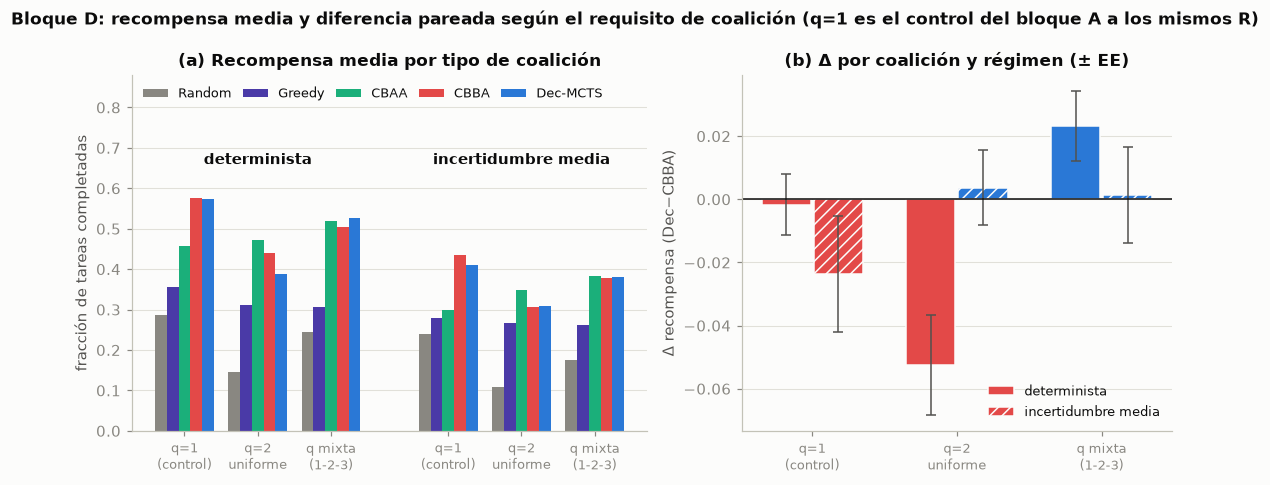

In [19]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.2, 4.2), gridspec_kw={'width_ratios': [1.2, 1]})

qs  = ['q1', 'q2', 'qm']
eti = ['q=1\n(control)', 'q=2\nuniforme', 'q mixta\n(1-2-3)']
x, w = np.arange(3), 0.16
# (a) niveles por coalición, los dos regímenes uno al lado del otro
for j, reg in enumerate(('det', 'est')):
    sub = combD[combD.regimen == reg].groupby('coalicion', observed=True)[SOLVERS].mean().reindex(qs)
    for k, s in enumerate(SOLVERS):
        ax1.bar(x + j * 3.6 + (k - 2) * w, sub[s].values, w, color=COLOR[s],
                label=NOMBRE[s] if j == 0 else None)
ax1.set_xticks(list(x) + list(x + 3.6), eti + eti, fontsize=8.2)
ax1.text(1, 0.66, 'determinista', ha='center', fontsize=9.5, color=INK, fontweight='semibold')
ax1.text(4.6, 0.66, 'incertidumbre media', ha='center', fontsize=9.5, color=INK, fontweight='semibold')
ax1.set_ylim(0, 0.88); ax1.set_ylabel('fracción de tareas completadas')
ax1.set_title('(a) Recompensa media por tipo de coalición')
ax1.legend(ncol=5, fontsize=8.2, loc='upper left', columnspacing=.9)
ax1.grid(axis='x', visible=False)

# (b) Δ por coalición y régimen
for j, (reg, hatch, lab) in enumerate((('det', None, 'determinista'), ('est', '///', 'incertidumbre media'))):
    d = combD[combD.regimen == reg].groupby('coalicion', observed=True).delta.agg(['mean', 'sem']).reindex(qs)
    ax2.bar(x + (j - .5) * .36, d['mean'], .34, yerr=d['sem'], hatch=hatch, label=lab,
            color=[POS if v > 0 else NEG for v in d['mean']], edgecolor=SURFACE,
            error_kw=dict(ecolor=INK2, elinewidth=1, capsize=3))
ax2.axhline(0, color=INK, lw=1)
ax2.set_xticks(x, eti, fontsize=8.5); ax2.set_ylabel('Δ recompensa (Dec−CBBA)')
ax2.set_title('(b) Δ por coalición y régimen (± EE)')
ax2.legend(fontsize=8.5, loc='lower right'); ax2.grid(axis='x', visible=False)

fig.suptitle('Bloque D: recompensa media y diferencia pareada según el requisito de coalición '
             '(q=1 es el control del bloque A a los mismos R)',
             fontsize=11, fontweight='semibold', y=1.02, color=INK)
guardar(fig, 'p2_D_coaliciones'); plt.show()

**Resultados.** Dos observaciones, ambas específicas de este bloque.

**1 · `CBAA` obtiene la media más alta del bloque**: 0.431, frente a 0.407 de `CBBA` y 0.401 de
`Dec-MCTS`, y alcanza la máxima recompensa en **45 de los 72 escenarios**. Es el único corte del
catálogo en que la subasta de **tarea única** supera a la de **paquete**; en todos los demás la
ordenación es la contraria (§1.1).

**2 · Los dos tipos de coalición producen Δ de signo opuesto** pese a compartir $\bar q = 2$ y
carga: `q2` da **−0.052 ± 0.016** en determinista y `qm` **+0.023 ± 0.011**. En régimen
estocástico ambas son indistinguibles de cero (+0.004 ± 0.012 y +0.001 ± 0.015). El efecto de
`q2` se acentúa con el tamaño del equipo: −0.006 con 3 robots, −0.059 con 6 y −0.093 con 10.

*Interpretación (hipótesis)*: el modelo de bloqueo de Dec-MCTS (`blockingProb`) decide de forma
**binaria** si los vecinos cubren una tarea, comprobando si al menos $q_j$ de ellos la llevan en
su paquete. Con requisitos homogéneos esa decisión se toma en las mismas condiciones para todas
las tareas, mientras que con requisitos heterogéneos las decisiones son de dificultad desigual;
el contraste `q2` / `qm` es compatible con esa diferencia. En cuanto a `CBAA`, una explicación
plausible es que comprometerse con un paquete de tareas futuras reduce la disponibilidad para
formar coaliciones en el instante en que se requieren, mientras que pujar por una tarea cada vez
la conserva. Ninguna de las dos se contrasta aquí.

Conviene registrar que **el efecto de `q2` ya está presente en régimen determinista**, donde el
resto de los contrastes de este cuaderno no muestra desventaja para Dec-MCTS: no es un efecto
atribuible a la incertidumbre.

## 2.5 · Bloque E — gradiente de incertidumbre

Único bloque que barre la incertidumbre como factor: cuatro niveles
$\rho \in \{1.0, 0.9, 0.75, 0.5\}$ con $\sigma \in \{0, 1, 3, 5\}$ sobre la duración —coeficiente
de variación 0 / 0.1 / 0.3 / 0.5— en tres tamaños de equipo. Es el único bloque **sin mitad
determinista**, por definición: el régimen determinista *es* $\rho = 1.0$, un extremo del propio
gradiente. Por esta razón todas las figuras del cuaderno cuyo eje recorre los cuatro regímenes se
construyen sobre este bloque.

In [20]:
E = W[W.bloque == 'E']
print('Recompensa media a lo largo del gradiente de incertidumbre')
display(E.groupby('regimen', observed=True).apply(fila, include_groups=False).reindex(REGS).round(3))
print('\nΔ pareada por nivel de incertidumbre y tamaño de equipo')
display(E.pivot_table(index='regimen', columns='robots', values='delta').reindex(REGS).round(3))
g = E.groupby('regimen')[SOLVERS].mean().reindex(REGS)
print('\nVariación relativa de ρ=1 a ρ=0.5 (%):')
display(((g.loc['fue'] - g.loc['det']) / g.loc['det'] * 100).rename(NOMBRE).round(1).to_frame('%'))

Recompensa media a lo largo del gradiente de incertidumbre


,Random,Greedy,CBAA,CBBA,Dec-MCTS,Δ,EE,t,n,G,E,P,máx.
regimen,,,,,,,,,,,,,
det,0.302,0.365,0.524,0.563,0.570,0.007,0.007,0.940,18.0,6.0,5.0,7.0,Dec-MCTS
lev,0.261,0.340,0.471,0.520,0.510,-0.010,0.015,-0.645,18.0,4.0,3.0,11.0,CBBA
est,0.241,0.295,0.369,0.452,0.428,-0.024,0.013,-1.864,18.0,7.0,0.0,11.0,CBBA
fue,0.162,0.207,0.263,0.328,0.278,-0.050,0.017,-2.968,18.0,4.0,0.0,14.0,CBBA



Δ pareada por nivel de incertidumbre y tamaño de equipo


robots,2,5,10
regimen,,,
det,0.028,0.006,-0.013
lev,0.037,-0.006,-0.061
est,-0.000,0.004,-0.076
fue,0.005,-0.052,-0.102



Variación relativa de ρ=1 a ρ=0.5 (%):


,%
Random,-46.4
Greedy,-43.3
CBAA,-49.9
CBBA,-41.8
Dec-MCTS,-51.2


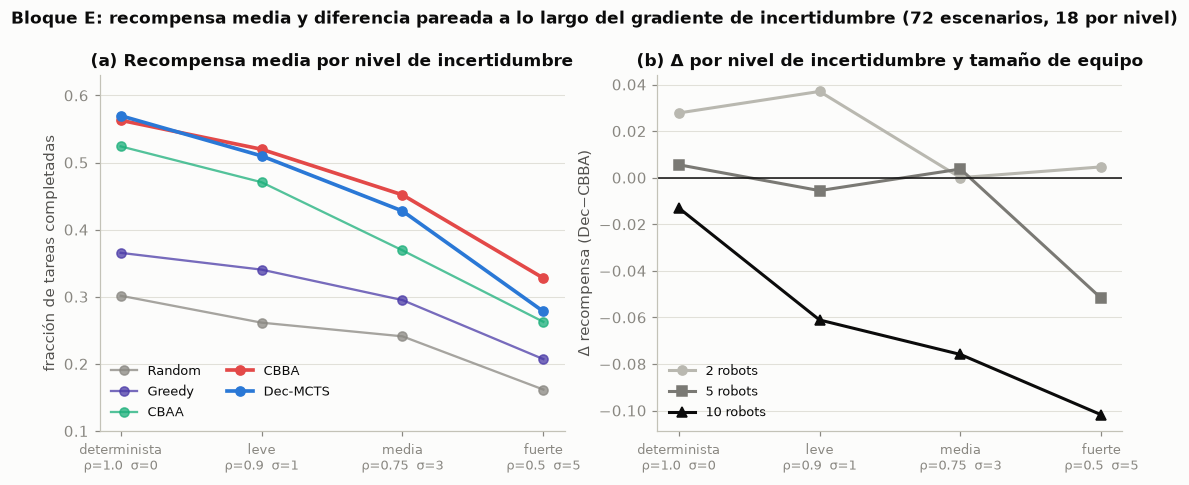

In [21]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.2))

# (a) degradación de los cinco solvers
for s in SOLVERS:
    y = E.groupby('regimen')[s].mean().reindex(REGS)
    ax1.plot(range(4), y.values, marker='o', color=COLOR[s], label=NOMBRE[s],
             lw=2.4 if s in (DEC, REF) else 1.5, zorder=3 if s in (DEC, REF) else 2,
             alpha=1 if s in (DEC, REF) else .75)
ax1.set_xticks(range(4), [REGIMEN[r] for r in REGS], fontsize=8.5)
ax1.set_ylabel('fracción de tareas completadas'); ax1.set_ylim(0.10, 0.63)
ax1.set_title('(a) Recompensa media por nivel de incertidumbre')
ax1.legend(fontsize=8.5, ncol=2, loc='lower left'); ax1.grid(axis='x', visible=False)

# (b) Δ frente a la incertidumbre, por tamaño de equipo
for R, mk in zip((2, 5, 10), ('o', 's', '^')):
    y = E[E.robots == R].groupby('regimen').delta.mean().reindex(REGS)
    ax2.plot(range(4), y.values, marker=mk, label=f'{R} robots', lw=2, color=C_TAM[R])
ax2.axhline(0, color=INK, lw=1)
ax2.set_xticks(range(4), [REGIMEN[r] for r in REGS], fontsize=8.5)
ax2.set_ylabel('Δ recompensa (Dec−CBBA)')
ax2.set_title('(b) Δ por nivel de incertidumbre y tamaño de equipo')
ax2.legend(fontsize=8.5, loc='lower left'); ax2.grid(axis='x', visible=False)

fig.suptitle('Bloque E: recompensa media y diferencia pareada a lo largo del gradiente de incertidumbre '
             '(72 escenarios, 18 por nivel)',
             fontsize=11, fontweight='semibold', y=1.02, color=INK)
guardar(fig, 'p2_E_incertidumbre'); plt.show()

**Resultados.** Los cinco solvers decrecen de forma monótona a lo largo del gradiente, pero con
pérdidas relativas distintas entre $\rho=1$ y $\rho=0.5$: `Dec-MCTS` **−51.2 %**, `CBAA` −49.9 %,
`Random` −46.4 %, `Greedy` −43.3 % y `CBBA` **−41.8 %**, la menor de las cinco. En valores
absolutos, `Dec-MCTS` tiene la media más alta en $\rho=1$ (0.570 frente a 0.563) y `CBBA` en
$\rho=0.5$ (0.328 frente a 0.278).

El panel (b) descompone la Δ por tamaño de equipo y muestra que ambos factores **interactúan**:

| | ρ=1.0 | ρ=0.9 | ρ=0.75 | ρ=0.5 |
|---|---|---|---|---|
| 2 robots | +0.028 | +0.037 | −0.000 | +0.005 |
| 5 robots | +0.006 | −0.006 | +0.004 | −0.052 |
| 10 robots | −0.013 | −0.061 | −0.076 | −0.102 |

Con 2 robots la Δ no es negativa en ninguno de los cuatro niveles; con 10 robots pasa de −0.013 a
−0.102 a lo largo del mismo gradiente. Ni la incertidumbre ni el tamaño del equipo explican por
separado el patrón observado.

*Interpretación (hipótesis)*: la estabilidad relativa de `CBBA` es compatible con la naturaleza de
lo que comunica. Una puja transmite un **precio**, que se recalcula en la siguiente ronda, mientras
que Dec-MCTS condiciona sus estimaciones sobre **trayectorias** muestreadas de los vecinos, cuya
validez se degrada cuando los tiempos y los desenlaces dejan de ser predecibles. El bloque es
consistente con esta lectura y con la de §2.1, pero no la contrasta.

---

# Parte 3 · Análisis adicional

La métrica objetivo resume el resultado, pero no describe cómo se alcanza. Esta parte examina cinco
magnitudes registradas por el simulador que **no intervienen en la recompensa**: robots perdidos
por agotamiento de batería, descomposición de la recompensa en sus dos factores observables,
distancia recorrida, tiempo de cómputo y ocupación del horizonte temporal. Todas ellas son
descriptivas: sirven para caracterizar el comportamiento de cada política, no para reordenarla.

## 3.1 · Robots perdidos por agotamiento de batería

Un robot se pierde cuando agota la batería sin alcanzar una estación de recarga; queda excluido del
escenario durante el resto de la ejecución. Es un **modo de fallo distinto de la mala asignación**
y por eso se contabiliza aparte.

El mecanismo está en el código y se verifica en los registros: si al arrancar una tarea el robot no
dispone de batería suficiente, el simulador fuerza `success = false` y trunca la ejecución
(`simulator.cpp:469-473`); a continuación `endTask` le carga `averageFailDemand` **completa**
—10 unidades— porque `averageFailTime == 0` (`simulator.cpp:494-498`). El cargo puede dejar la
batería en negativo (ejemplo registrado: 3.16 → −6.84). La condición **no requiere incertidumbre**,
de modo que también se produce con $\rho = 1$.

In [22]:
MU = ancho('muertos')
tab = pd.DataFrame({'robots perdidos / escenario': MU[SOLVERS].mean(),
                    '% escenarios con bajas': 100 * (MU[SOLVERS] > 0).mean(),
                    'det': MU[MU.regimen == 'det'][SOLVERS].mean(),
                    'lev': MU[MU.regimen == 'lev'][SOLVERS].mean(),
                    'est': MU[MU.regimen == 'est'][SOLVERS].mean(),
                    'fue': MU[MU.regimen == 'fue'][SOLVERS].mean()}).rename(index=NOMBRE)
display(tab.round(3))
print('cbaa, cbba y dec-mcts: cero robots perdidos en las 5 400 ejecuciones del catálogo.')

,robots perdidos / escenario,% escenarios con bajas,det,lev,est,fue
Random,1.984,85.278,1.854,1.704,2.115,2.259
Greedy,1.441,66.944,1.267,0.852,1.640,1.796
CBAA,0.000,0.000,0.000,0.000,0.000,0.000
CBBA,0.000,0.000,0.000,0.000,0.000,0.000
Dec-MCTS,0.000,0.000,0.000,0.000,0.000,0.000


cbaa, cbba y dec-mcts: cero robots perdidos en las 5 400 ejecuciones del catálogo.


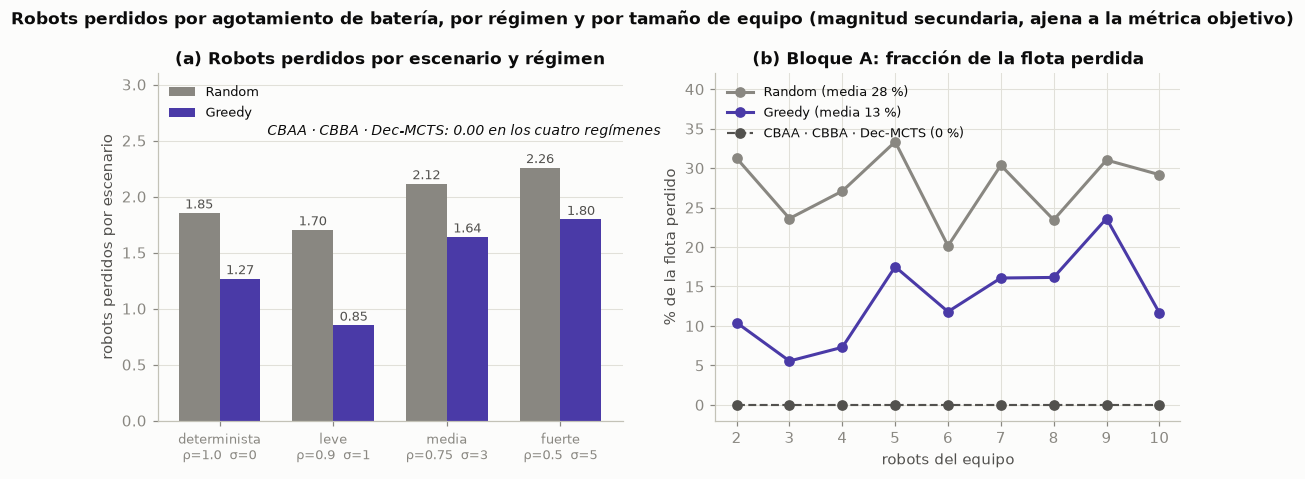

In [23]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.1))

# (a) muertos por régimen
x, w = np.arange(4), 0.36
for j, s in enumerate(('random', 'greedy')):
    y = [MU[MU.regimen == r][s].mean() for r in REGS]
    ax1.bar(x + (j - .5) * w, y, w, color=COLOR[s], label=NOMBRE[s])
    for i, v in enumerate(y):
        ax1.text(i + (j - .5) * w, v + .04, f'{v:.2f}', ha='center', fontsize=8.5, color=INK2)
ax1.text(2.15, 2.55, 'CBAA · CBBA · Dec-MCTS: 0.00 en los cuatro regímenes',
         ha='center', fontsize=9, color=INK, style='italic')
ax1.set_xticks(x, [REGIMEN[r] for r in REGS], fontsize=8.5)
ax1.set_ylim(0, 3.1); ax1.set_ylabel('robots perdidos por escenario')
ax1.set_title('(a) Robots perdidos por escenario y régimen')
ax1.legend(fontsize=8.5, loc='upper left'); ax1.grid(axis='x', visible=False)

# (b) fracción de la flota perdida frente al tamaño del equipo (bloque A, iso-dificultad)
a = MU[MU.bloque == 'A']
for s in ('random', 'greedy'):
    y = (a[s] / a.robots).groupby(a.robots).mean()
    ax2.plot(y.index, 100 * y.values, marker='o', color=COLOR[s],
             label=f'{NOMBRE[s]} (media {100 * (a[s] / a.robots).mean():.0f} %)')
ax2.plot(range(2, 11), [0] * 9, marker='o', color=INK2, ls='--', lw=1.4,
         label='CBAA · CBBA · Dec-MCTS (0 %)')
ax2.set_xticks(range(2, 11)); ax2.set_xlabel('robots del equipo')
ax2.set_ylabel('% de la flota perdido'); ax2.set_ylim(-2, 42)
ax2.set_title('(b) Bloque A: fracción de la flota perdida')
ax2.legend(fontsize=8.5, loc='upper left')

fig.suptitle('Robots perdidos por agotamiento de batería, por régimen y por tamaño de equipo '
             '(magnitud secundaria, ajena a la métrica objetivo)',
             fontsize=11, fontweight='semibold', y=1.02, color=INK)
guardar(fig, 'p3_mortalidad'); plt.show()

**Resultados.** `Random` pierde **1.98 robots por escenario** y registra bajas en el 85.3 % de los
escenarios; `Greedy`, **1.44** y 66.9 %. `CBAA`, `CBBA` y `Dec-MCTS` no pierden **ningún robot en
las 5 400 ejecuciones**, en ninguno de los cuatro regímenes.

Sobre el bloque A, que mantiene la dificultad constante al crecer el equipo, la magnitud que se
conserva es la **fracción de flota**: `Random` pierde el 27.7 % de sus robots con independencia del
tamaño del equipo (correlación de la fracción con $n$: r = 0.01, frente a r = 0.72 del recuento
absoluto) y `Greedy` el 13.3 %, con una leve tendencia creciente (r = 0.23).

La diferencia se corresponde con una diferencia de implementación verificable: los tres solvers
coordinados comprueban, antes de comprometerse con una tarea, que la batería alcanza para
**ejecutarla**, y no solo para **llegar** hasta ella.

⚠️ **Consecuencia para la interpretación del resto del cuaderno**: una parte no cuantificada de la
distancia que separa a los tres solvers coordinados de `Random` y `Greedy` —entre 0.08 (CBAA frente
a Greedy) y 0.23 (Dec-MCTS frente a Random) en el agregado— corresponde a este modo de fallo y no
a la calidad de la asignación. Al comparar contra ambos baselines debe declararse. La comparación
entre `Dec-MCTS` y `CBBA` no está afectada: ninguno de los dos pierde robots en ningún escenario.

## 3.2 · Descomposición de la recompensa: tasa de intento y tasa de éxito

La fracción de tareas completadas se factoriza de forma exacta en dos magnitudes observables:

$$\text{recompensa} \;=\; \underbrace{\frac{\text{tareas intentadas}}{n}}_{\text{tasa de intento}}
\;\times\; \underbrace{\frac{\text{tareas completadas}}{\text{tareas intentadas}}}_{\text{tasa de éxito}}$$

La primera mide la **cobertura**: cuántas de las tareas del escenario llega a emprender el equipo.
La segunda mide el **acierto**: qué fracción de lo emprendido se termina. Se reportan ambas por
régimen y, para cuantificar cuál de las dos acompaña a la diferencia de recompensa, la correlación
de $\Delta\text{recompensa}$ con la diferencia de cada término.

In [24]:
WI, WE = ancho('intento'), ancho('exito')
comp = pd.concat({'tasa de intento': WI.groupby('regimen')[SOLVERS].mean().reindex(REGS),
                  'tasa de éxito':   WE.groupby('regimen')[SOLVERS].mean().reindex(REGS)},
                 axis=1).rename(columns=NOMBRE)
display(comp.round(3))

di, de = WI[DEC] - WI[REF], (WE[DEC] - WE[REF]).fillna(0)
print(f'Correlación de la Δ de recompensa con…  Δ tasa de intento r = {np.corrcoef(W.delta, di)[0,1]:.3f}'
      f'   ·   Δ tasa de éxito r = {np.corrcoef(W.delta, de)[0,1]:.3f}')
print('\nTareas distintas que el equipo llega a intentar (media por escenario):')
display(esc.pivot_table(index='regimen', columns='solver', values='intentadas')
           .reindex(REGS)[SOLVERS].rename(columns=NOMBRE).round(2))

tasa de intento                               tasa de éxito         \
                 Random Greedy   CBAA   CBBA Dec-MCTS        Random Greedy   
regimen                                                                      
det               0.363  0.439  0.512  0.565    0.585         0.874  0.928   
lev               0.348  0.403  0.526  0.582    0.561         0.766  0.854   
est               0.393  0.483  0.516  0.615    0.593         0.643  0.690   
fue               0.399  0.471  0.540  0.679    0.588         0.417  0.451   

                                
          CBAA   CBBA Dec-MCTS  
regimen                         
det      1.000  1.000    1.000  
lev      0.897  0.896    0.910  
est      0.737  0.719    0.754  
fue      0.494  0.481    0.478

Correlación de la Δ de recompensa con…  Δ tasa de intento r = 0.768   ·   Δ tasa de éxito r = 0.417

Tareas distintas que el equipo llega a intentar (media por escenario):


solver,Random,Greedy,CBAA,CBBA,Dec-MCTS
regimen,,,,,
det,11.01,13.33,14.91,17.51,17.64
lev,11.89,13.57,17.35,20.94,19.57
est,11.90,14.71,14.64,19.26,17.75
fue,13.63,15.98,16.89,25.02,20.09


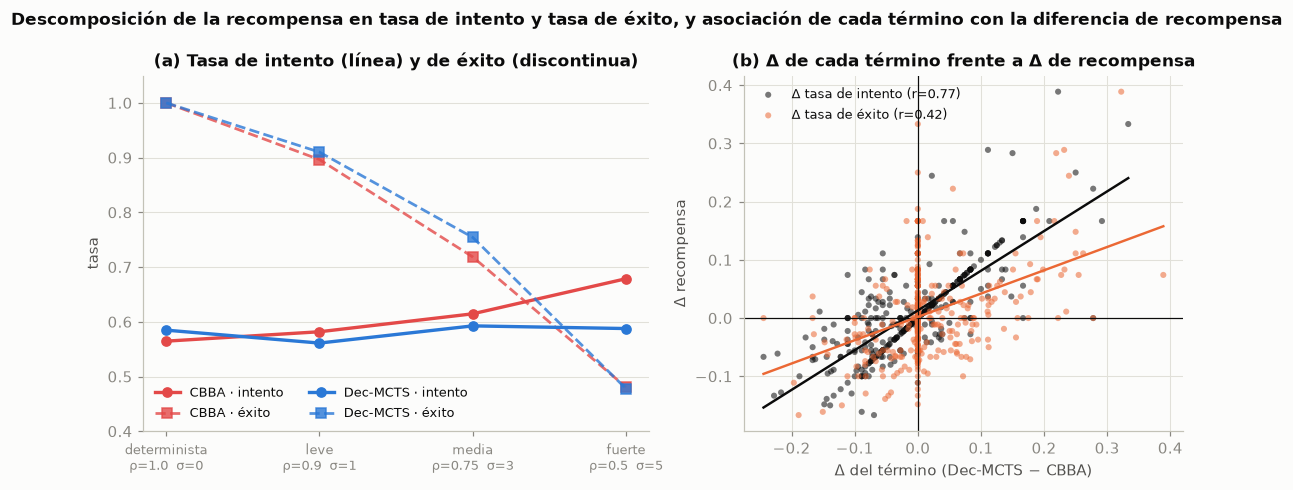

In [25]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.2, 4.2), gridspec_kw={'width_ratios': [1.15, 1]})

# (a) intento y éxito de Dec-MCTS y CBBA a lo largo del gradiente
for s in (REF, DEC):
    ax1.plot(range(4), WI.groupby('regimen')[s].mean().reindex(REGS).values, marker='o',
             color=COLOR[s], lw=2.2, label=f'{NOMBRE[s]} · intento')
    ax1.plot(range(4), WE.groupby('regimen')[s].mean().reindex(REGS).values, marker='s', ls='--',
             color=COLOR[s], lw=1.8, alpha=.8, label=f'{NOMBRE[s]} · éxito')
ax1.set_xticks(range(4), [REGIMEN[r] for r in REGS], fontsize=8.5)
ax1.set_ylabel('tasa'); ax1.set_ylim(0.40, 1.05)
ax1.set_title('(a) Tasa de intento (línea) y de éxito (discontinua)')
ax1.legend(fontsize=8.2, ncol=2, loc='lower left'); ax1.grid(axis='x', visible=False)

# (b) qué término acompaña a la Δ de recompensa
ax2.axhline(0, color=INK, lw=.8); ax2.axvline(0, color=INK, lw=.8)
ax2.scatter(di, W.delta, s=16, alpha=.55, color=INK, edgecolor='none',
            label=f'Δ tasa de intento (r={np.corrcoef(W.delta, di)[0,1]:.2f})')
ax2.scatter(de, W.delta, s=16, alpha=.55, color=C_REG['est'], edgecolor='none',
            label=f'Δ tasa de éxito (r={np.corrcoef(W.delta, de)[0,1]:.2f})')
for v, c in ((di, INK), (de, C_REG['est'])):
    b, a = np.polyfit(v, W.delta, 1); xs = np.linspace(v.min(), v.max(), 2)
    ax2.plot(xs, a + b * xs, color=c, lw=1.6)
ax2.set_xlabel('Δ del término (Dec-MCTS − CBBA)'); ax2.set_ylabel('Δ recompensa')
ax2.set_title('(b) Δ de cada término frente a Δ de recompensa')
ax2.legend(fontsize=8.5, loc='upper left')

fig.suptitle('Descomposición de la recompensa en tasa de intento y tasa de éxito, '
             'y asociación de cada término con la diferencia de recompensa',
             fontsize=11, fontweight='semibold', y=1.02, color=INK)
guardar(fig, 'p3_mecanismo'); plt.show()

**Resultados.** Los dos términos se comportan de forma distinta entre `Dec-MCTS` y `CBBA`:

| | tasa de intento | | tasa de éxito | |
|---|---|---|---|---|
| | CBBA | Dec-MCTS | CBBA | Dec-MCTS |
| determinista | 0.565 | **0.585** | 1.000 | 1.000 |
| leve | **0.582** | 0.561 | 0.896 | **0.910** |
| media | **0.615** | 0.593 | 0.719 | **0.754** |
| fuerte | **0.679** | 0.588 | 0.481 | 0.478 |

- La **tasa de éxito** de `Dec-MCTS` es igual o superior a la de `CBBA` en los tres primeros
  regímenes (+0.014 en leve, +0.035 en media) y equivalente en el cuarto. De las tareas que
  emprende, `Dec-MCTS` termina una fracción igual o mayor.
- La **tasa de intento** se invierte con el régimen: `Dec-MCTS` emprende más tareas que `CBBA` en
  determinista (0.585 frente a 0.565) y menos en los tres regímenes con incertidumbre, con una
  diferencia que crece hasta −0.091 en el más severo (17.75 frente a 19.26 tareas distintas por
  escenario en régimen medio).
- La correlación de la Δ de recompensa es **r = 0.77 con la Δ de tasa de intento** y **r = 0.42
  con la Δ de tasa de éxito**.

La diferencia de recompensa bajo incertidumbre, por tanto, **no procede de un menor acierto al
elegir tareas, sino de una menor cobertura**. El dato es el que anticipaba el patrón de §2.1: el
déficit de cobertura aparece únicamente en presencia de incertidumbre.

*Nota sobre la tasa de éxito en régimen determinista*: los tres solvers coordinados alcanzan
exactamente 1.000, lo que es coherente con la ausencia de bajas de §3.1; `Random` (0.874) y
`Greedy` (0.928) no lo hacen, por el mecanismo de arranque sin batería allí descrito.

## 3.3 · Distancia recorrida

Distancia acumulada por los robots durante la ejecución, en tres formas: media por robot, total por
escenario y **normalizada por tarea completada**, que expresa el desplazamiento que cada política
paga por unidad de resultado. Es una magnitud de coste operativo: no entra en la recompensa, pero
condiciona el consumo de batería y, con ello, el rendimiento alcanzable si se encarece la
navegación.

In [26]:
DR, DT, CO = ancho('dist_robot'), ancho('distancia'), ancho('completadas')
efic = (DT[SOLVERS] / CO[SOLVERS].replace(0, np.nan))
dist = pd.DataFrame({'distancia por robot': DR[SOLVERS].mean(),
                     'distancia total': DT[SOLVERS].mean(),
                     'distancia por tarea completada': efic.mean(),
                     'det': DR[DR.regimen == 'det'][SOLVERS].mean(),
                     'est': DR[DR.regimen == 'est'][SOLVERS].mean(),
                     'fue': DR[DR.regimen == 'fue'][SOLVERS].mean()}).rename(index=NOMBRE)
display(dist.round(2))
print(f'Distancia de Dec-MCTS relativa a CBBA: '
      f'{100 * (DR[DEC].mean() / DR[REF].mean() - 1):+.1f} % por robot, '
      f'{100 * (efic[DEC].mean() / efic[REF].mean() - 1):+.1f} % por tarea completada.')

,distancia por robot,distancia total,distancia por tarea completada,det,est,fue
Random,15.94,93.42,16.44,15.50,16.41,16.45
Greedy,10.75,58.52,7.46,10.58,10.94,10.86
CBAA,13.93,76.25,7.13,13.90,13.81,14.59
CBBA,15.50,91.78,7.44,14.60,16.04,18.75
Dec-MCTS,19.42,114.11,8.86,17.81,20.53,22.91


Distancia de Dec-MCTS relativa a CBBA: +25.3 % por robot, +19.1 % por tarea completada.


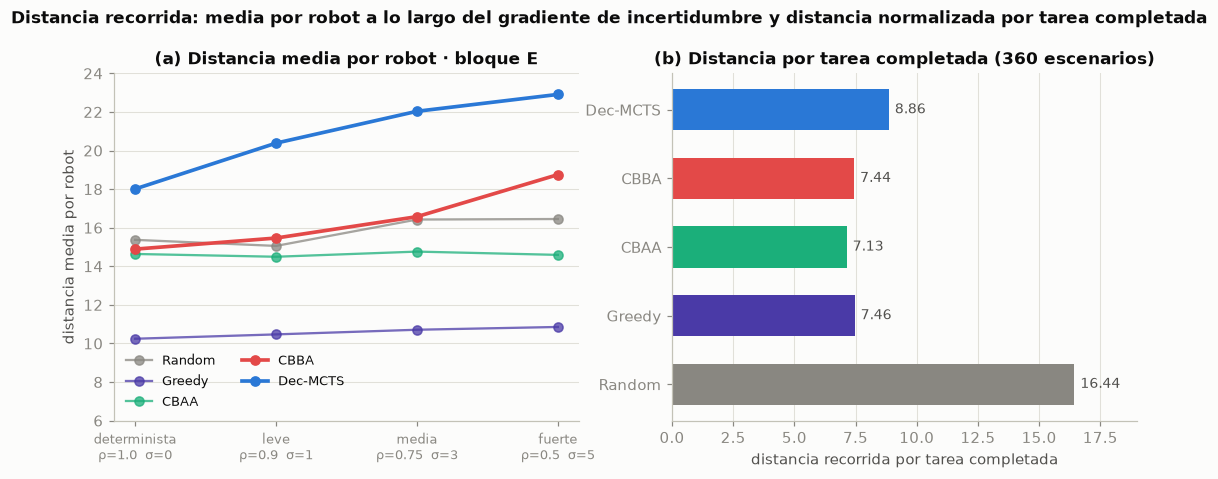

In [27]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.1))

# (a) distancia por robot a lo largo del gradiente (bloque E, el único con los cuatro niveles)
E_idx = DR.bloque == 'E'
for s in SOLVERS:
    y = DR[E_idx].groupby('regimen')[s].mean().reindex(REGS)
    ax1.plot(range(4), y.values, marker='o', color=COLOR[s], label=NOMBRE[s],
             lw=2.4 if s in (DEC, REF) else 1.5, alpha=1 if s in (DEC, REF) else .75)
ax1.set_xticks(range(4), [REGIMEN[r] for r in REGS], fontsize=8.5)
ax1.set_ylabel('distancia media por robot'); ax1.set_ylim(6, 24)
ax1.set_title('(a) Distancia media por robot · bloque E')
ax1.legend(fontsize=8.5, ncol=2, loc='lower left'); ax1.grid(axis='x', visible=False)

# (b) distancia pagada por cada tarea completada
m = efic.mean().reindex(SOLVERS)
ax2.barh(range(5), m.values, .6, color=[COLOR[s] for s in m.index])
ax2.set_yticks(range(5), [NOMBRE[s] for s in m.index])
for i, v in enumerate(m.values):
    ax2.text(v + .25, i, f'{v:.2f}', va='center', fontsize=9, color=INK2)
ax2.set_xlim(0, 19); ax2.set_xlabel('distancia recorrida por tarea completada')
ax2.set_title('(b) Distancia por tarea completada (360 escenarios)')
ax2.grid(axis='y', visible=False)

fig.suptitle('Distancia recorrida: media por robot a lo largo del gradiente de incertidumbre '
             'y distancia normalizada por tarea completada',
             fontsize=11, fontweight='semibold', y=1.02, color=INK)
guardar(fig, 'p3_distancia'); plt.show()

**Resultados.** `Dec-MCTS` recorre **19.42 unidades por robot** frente a las 15.50 de `CBBA`
(**+25.3 %**), y la diferencia relativa aumenta con la incertidumbre (+22 % en determinista,
+28 % en régimen medio, +22 % en el fuerte, sobre el bloque E). Normalizando por resultado, paga
**8.86 de distancia por tarea completada**, frente a 7.44 de `CBBA` y 7.13 de `CBAA`, el valor más
bajo de los cinco.

`Random` es el caso extremo opuesto: recorre 15.94 por robot —tanto como `CBBA`— pero **16.44 por
tarea completada**, aproximadamente el doble que cualquier otro solver, porque una fracción
sustancial de ese recorrido termina en tareas fallidas o en robots que agotan la batería (§3.1).

*Observación operativa*: el sobrecoste de desplazamiento es neutro mientras la navegación sea
barata, pero acota el rendimiento cuando el desplazamiento es el recurso limitante. En pruebas
realizadas durante el desarrollo con navegación cara y batería escasa, `Dec-MCTS` no superó a
`CBBA` en ninguno de los 12 escenarios medidos; esa configuración no forma parte del catálogo v3 y
el dato se cita solo como referencia de contexto.

## 3.4 · Tiempo de cómputo

Tiempo de CPU acumulado por la política durante la ejecución, tal como lo registra el simulador en
`computing_time`.

⚠️ **Condiciones de medida.** La tanda se ejecutó con **6 procesos en paralelo** sobre la misma
máquina, de modo que los tiempos incorporan contención por CPU y **no son comparables con una
ejecución aislada** en valor absoluto. Las comparaciones **entre solvers** y las **tendencias** sí
son válidas, porque todas las ejecuciones se realizaron en las mismas condiciones. El número de
iteraciones de MCTS es un parámetro fijo, por lo que el tiempo empleado no afecta a la calidad de
las soluciones obtenidas: una implementación más rápida produciría los mismos resultados.

In [28]:
CP = ancho('cpu')
cost = pd.DataFrame({'s / ejecución (media)': CP[SOLVERS].mean(),
                     'mediana': CP[SOLVERS].median(),
                     'máximo': CP[SOLVERS].max(),
                     'veces CBBA': CP[SOLVERS].mean() / CP[REF].mean()}).rename(index=NOMBRE)
display(cost.round(4))
print('\nTiempo frente al tamaño del equipo (bloque A, s por ejecución):')
display(CP[CP.bloque == 'A'].groupby('robots')[SOLVERS].mean().rename(columns=NOMBRE).round(3))

,s / ejecución (media),mediana,máximo,veces CBBA
Random,0.0009,0.0007,0.0045,0.1111
Greedy,0.0011,0.0008,0.0092,0.1330
CBAA,0.0015,0.0011,0.0184,0.1818
CBBA,0.0082,0.0023,0.0794,1.0000
Dec-MCTS,15.3227,6.7945,88.2828,1863.5956



Tiempo frente al tamaño del equipo (bloque A, s por ejecución):


,Random,Greedy,CBAA,CBBA,Dec-MCTS
robots,,,,,
2,0.000,0.000,0.000,0.000,0.552
3,0.000,0.000,0.000,0.001,1.604
4,0.001,0.002,0.001,0.001,3.771
5,0.001,0.001,0.001,0.003,6.453
6,0.001,0.001,0.001,0.004,11.197
7,0.001,0.001,0.002,0.006,15.129
8,0.001,0.002,0.002,0.009,23.209
9,0.002,0.003,0.003,0.018,31.953
10,0.002,0.002,0.003,0.024,44.405


findfont: Failed to find font weight semibold, now using 700.


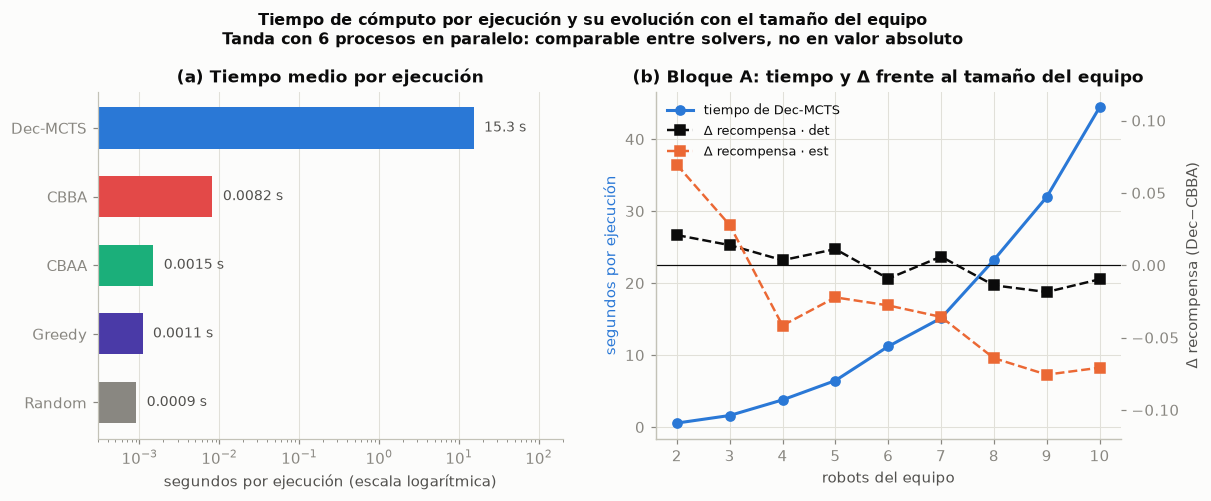

In [29]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.1))

# (a) coste por solver, escala logarítmica
m = CP[SOLVERS].mean().reindex(SOLVERS)
ax1.barh(range(5), m.values, .6, color=[COLOR[s] for s in m.index])
ax1.set_yticks(range(5), [NOMBRE[s] for s in m.index]); ax1.set_xscale('log')
for i, v in enumerate(m.values):
    ax1.text(v * 1.35, i, f'{v:.4f} s' if v < 1 else f'{v:.1f} s', va='center', fontsize=9, color=INK2)
ax1.set_xlim(3e-4, 2e2); ax1.set_xlabel('segundos por ejecución (escala logarítmica)')
ax1.set_title('(a) Tiempo medio por ejecución'); ax1.grid(axis='y', visible=False)

# (b) cómo escala el coste frente a la diferencia de recompensa
a = CP[CP.bloque == 'A']
ax2.plot(a.groupby('robots')[DEC].mean().index, a.groupby('robots')[DEC].mean().values,
         marker='o', color=COLOR[DEC], label='tiempo de Dec-MCTS')
ax2.set_xlabel('robots del equipo'); ax2.set_ylabel('segundos por ejecución', color=COLOR[DEC])
ax2.set_xticks(range(2, 11)); ax2.set_title('(b) Bloque A: tiempo y Δ frente al tamaño del equipo')
ax3 = ax2.twinx(); ax3.grid(False)
for reg, lab in (('det', 'Δ recompensa · det'), ('est', 'Δ recompensa · est')):
    y = W[(W.bloque == 'A') & (W.regimen == reg)].groupby('robots').delta.mean()
    ax3.plot(y.index, y.values, marker='s', ls='--', lw=1.6, color=C_REG[reg], label=lab)
ax3.axhline(0, color=INK, lw=.8)
ax3.set_ylabel('Δ recompensa (Dec−CBBA)', color=INK2); ax3.set_ylim(-0.12, 0.12)
h1, l1 = ax2.get_legend_handles_labels(); h2, l2 = ax3.get_legend_handles_labels()
ax2.legend(h1 + h2, l1 + l2, fontsize=8.5, loc='upper left')

fig.suptitle('Tiempo de cómputo por ejecución y su evolución con el tamaño del equipo\n'
             'Tanda con 6 procesos en paralelo: comparable entre solvers, no en valor absoluto',
             fontsize=10.5, fontweight='semibold', y=1.06, color=INK)
guardar(fig, 'p3_coste'); plt.show()

**Resultados.** Los tiempos medios por ejecución separan a los cinco solvers en tres órdenes de
magnitud: `Random` 0.0009 s, `Greedy` 0.0011 s y `CBAA` 0.0015 s; `CBBA` **0.0082 s**; `Dec-MCTS`
**15.32 s** (mediana 6.79 s, máximo 88.28 s), es decir, **≈1 864 veces** el tiempo de `CBBA`.

Sobre el bloque A, el tiempo de `Dec-MCTS` crece de **0.55 s con 2 robots a 44.41 s con 10**,
mientras que la Δ de recompensa recorre el sentido contrario y cambia de signo en ese mismo
intervalo (§2.1). Las dos curvas del panel (b) resumen el compromiso: el coste marginal de la
búsqueda crece con el tamaño del equipo en el mismo tramo en que su ventaja desaparece.

Dos precisiones sobre lo que estos números **no** establecen: el coste es lineal en el presupuesto
de iteraciones, que es un hiperparámetro fijado durante el desarrollo, de modo que no caracteriza
un límite del método; y multiplicar ese presupuesto por 40 en pruebas anteriores no modificó el
rendimiento, por lo que tampoco cabe atribuir la diferencia de recompensa a un cómputo
insuficiente.

## 3.5 · Ocupación del horizonte temporal

Dos magnitudes temporales registradas por el simulador: el **makespan** del robot más tardío
—instante en que cesa la última actividad del equipo— y el **instante medio de retirada**, momento
en que cada robot deja de operar, ya sea por terminar su plan, por no disponer de tareas
alcanzables o por agotar la batería. Con horizonte $T = 40$ y ventanas que se extienden más allá,
ambas informan de qué parte del tiempo disponible aprovecha cada política. Las figuras se
construyen sobre el bloque E, único con los cuatro niveles de incertidumbre.

In [30]:
MK, RT = ancho('makespan'), ancho('retiro')
temp = pd.concat({'makespan máximo': MK.groupby('regimen')[SOLVERS].mean().reindex(REGS),
                  'instante medio de retirada': RT.groupby('regimen')[SOLVERS].mean().reindex(REGS)},
                 axis=1).rename(columns=NOMBRE)
display(temp.round(2))

makespan máximo                                \
                 Random Greedy   CBAA   CBBA Dec-MCTS   
regimen                                                 
det               53.69  54.46  58.96  57.34    60.46   
lev               55.19  56.38  58.90  58.07    59.59   
est               53.31  54.46  58.25  56.48    58.60   
fue               54.06  55.86  57.46  56.53    56.65   

        instante medio de retirada                                
                            Random Greedy   CBAA   CBBA Dec-MCTS  
regimen                                                           
det                          50.90  50.78  44.40  49.06    54.94  
lev                          52.15  52.20  43.57  49.12    54.53  
est                          50.92  51.03  37.40  46.21    52.41  
fue                          50.12  51.06  31.89  44.41    49.65

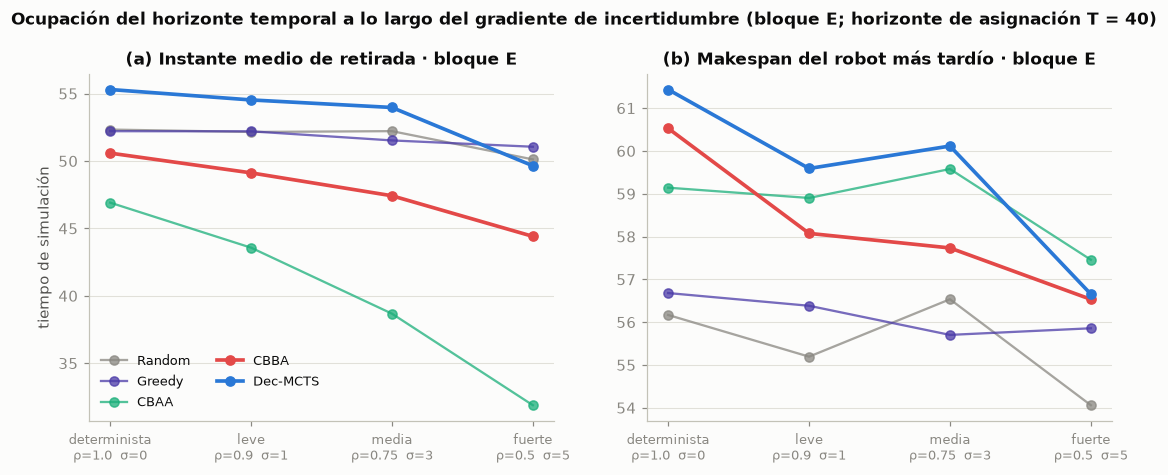

In [31]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.1))

for ax, T, tit in ((ax1, RT, '(a) Instante medio de retirada'),
                   (ax2, MK, '(b) Makespan del robot más tardío')):
    for s in SOLVERS:
        y = T[T.bloque == 'E'].groupby('regimen')[s].mean().reindex(REGS)
        ax.plot(range(4), y.values, marker='o', color=COLOR[s], label=NOMBRE[s],
                lw=2.4 if s in (DEC, REF) else 1.5, alpha=1 if s in (DEC, REF) else .75)
    ax.set_xticks(range(4), [REGIMEN[r] for r in REGS], fontsize=8.5)
    ax.set_title(tit + ' · bloque E'); ax.grid(axis='x', visible=False)
ax1.set_ylabel('tiempo de simulación'); ax1.legend(fontsize=8.5, ncol=2, loc='lower left')

fig.suptitle('Ocupación del horizonte temporal a lo largo del gradiente de incertidumbre '
             '(bloque E; horizonte de asignación T = 40)',
             fontsize=11, fontweight='semibold', y=1.02, color=INK)
guardar(fig, 'p3_tiempos'); plt.show()

**Resultados.** El instante medio de retirada ordena a los solvers y varía de forma desigual a lo
largo del gradiente. Sobre el conjunto del catálogo, `Dec-MCTS` registra los valores más altos
(54.94 en determinista, 52.41 en régimen medio) y `CBAA` los más bajos (44.40 y 37.40). Sobre el
bloque E, `Dec-MCTS` pasa de **55.3 a 49.7** entre $\rho=1$ y $\rho=0.5$, y `CBAA` de **46.9 a
31.9**.

`CBAA` no pierde robots por batería (§3.1), de modo que su retirada temprana corresponde a robots
que dejan de encontrar tareas alcanzables dentro de plazo y quedan inactivos. Es coherente con su
baja tasa de intento bajo incertidumbre (§3.2) y con su pendiente nula frente al tamaño del equipo
(§2.1): en las tres magnitudes, añadir robots no se traduce en más cobertura.

El makespan discrimina mucho menos —entre 53 y 61 en todos los cortes—: todas las políticas
mantienen algún robot activo hasta bien entrado el horizonte, de modo que la diferencia no está en
cuándo se detiene el último robot, sino en cuántos siguen operando hasta ese momento.

---

# Resumen de resultados

**Medidas obtenidas sobre el catálogo v3.**

1. **Ordenación agregada**: `Random` 0.271 < `Greedy` 0.354 < `CBAA` 0.437 < `CBBA` 0.494 <
   `Dec-MCTS` 0.502. Las tres primeras separaciones no cambian de signo en ningún corte del
   catálogo; en la matriz de dominancia, `Dec-MCTS` supera a `Random` en 358 de 360 escenarios y a
   `Greedy` en 333, y `CBBA` supera a `CBAA` en 209.
2. **La cuarta separación no queda determinada**: Δ = +0.0086 ± 0.0040, con 158 diferencias
   positivas frente a 160 negativas, mediana 0.000, y un signo del agregado que se invierte al
   excluir el bloque C del conjunto (§1.4).
3. **Por régimen**, la Δ es +0.0201 ± 0.0055 en determinista y −0.0497 ± 0.0167 en incertidumbre
   fuerte, e indistinguible de cero en los dos regímenes intermedios.
4. **Escalado con el tamaño del equipo** (bloque A, carga constante): bajo incertidumbre, la
   pendiente de `CBBA` es +0.0195 por robot ($t$ = 6.6) y la de `Dec-MCTS` +0.0040 ($t$ = 1.5); la
   pendiente de la propia Δ es −0.0155 por robot ($t$ = −4.7). `Random`, `Greedy` y `CBAA` tienen
   pendiente nula en ambos regímenes.
5. **Descomposición de la recompensa**: bajo incertidumbre, la tasa de éxito de `Dec-MCTS` es igual
   o superior a la de `CBBA`, y la diferencia de recompensa se asocia a la **tasa de intento**
   (r = 0.77 frente a r = 0.42).
6. **Cortes con Δ positiva**: plazo escalonado (+0.078, positiva en 12 de 12 escenarios), ventana
   sin espera (+0.038), carga holgada (+0.208 con 2 robots y L=3) y coalición mixta (+0.023).
   **Cortes con Δ negativa**: ventana ancha (−0.034, positiva en 0 de 12), coalición uniforme
   (−0.052), carga alta y equipos grandes bajo incertidumbre.
7. **Resultados propios de un bloque**: `CBAA` obtiene la media más alta del bloque de coaliciones
   (0.431 frente a 0.407 de `CBBA`) y el máximo en 45 de sus 72 escenarios; y las coaliciones
   uniforme y mixta producen Δ de signo opuesto pese a compartir $\bar q$ y carga.
8. **Magnitudes secundarias**: `Random` y `Greedy` pierden 1.98 y 1.44 robots por escenario y los
   tres solvers coordinados ninguno; `Dec-MCTS` recorre un 25.3 % más de distancia por robot que
   `CBBA` y un 19.1 % más por tarea completada; y su tiempo de cómputo es ≈1 864 veces el de
   `CBBA`, creciendo de 0.55 s a 44.41 s entre 2 y 10 robots.

**Condiciones que deben acompañar a la presentación de estos resultados.**

- El resultado agregado **depende de la composición del catálogo**: los niveles de los bloques B y
  C caen mayoritariamente en la región de Δ positiva y los de A, D y E en la de Δ negativa (§1.4).
- Los regímenes `lev` y `fue` proceden **solo del bloque E** (18 escenarios cada uno); `det` y
  `est` están equilibrados entre los cinco bloques.
- Parte de la distancia entre los solvers coordinados y los dos baselines corresponde a
  **robots perdidos por batería** y no a la calidad de la asignación (§3.1).
- Los **tiempos de cómputo** proceden de una tanda con 6 procesos en paralelo (§3.4).
- La **ventana escalonada** es ~5 unidades más apretada que la de solo plazo, lo que debe
  mencionarse al interpretar ese nivel (§2.2).
- La tanda **no es reproducible bit a bit**: el simulador no admite semilla configurable
  (`std::random_device`). Las 3 réplicas promedian la variabilidad, pero no la eliminan.
- Las explicaciones mecanísticas señaladas como *interpretación* en §2.1, §2.2, §2.4 y §2.5 son
  hipótesis compatibles con los datos; **este cuaderno mide asociaciones, no las contrasta**.